# Knowledge-Graph-Guided Spatial Proteomics of Murine Acute Kidney Injury

**A hypothesis-generating pilot study using IMC with INDRA/CoGEx biological context**

> **Methodological note (post-hoc reframing).** This notebook synthesizes a candidate hypothesis — *stromal-marker-positive tissue area appears less stromal-only and more multi-lineage at Sham→D7* — that emerged post-hoc during Gate 6 normalization sensitivity analysis (April 2026). The component analyses (DA, neighborhood, INDRA grounding) were designed BEFORE this hypothesis existed. The notebook presents convergent post-hoc readings of pre-existing analyses; it does NOT test the hypothesis. Testing requires an n≥10 follow-up cohort. Pre-registration: `analysis_plans/temporal_interfaces_plan.md`. Throughline (kidney companion notebook): `analysis_plans/kidney_notebook_throughline.md`.

This notebook synthesizes three analysis layers:
1. **Differential abundance** — cell-type proportion changes across AKI timepoints (Hedges' g effect sizes; Tier 3 context relative to the candidate finding)
2. **Spatial neighborhood architecture** — cell-type co-localization patterns via permutation-tested enrichment (Tier 3 context)
3. **INDRA knowledge graph context** — 117 intra-panel causal relationships grounding panel design and finding interpretation (NOT validation; Tier 3 context)

The **Tier 1 direct evidence** for the candidate finding lives in the companion kidney notebook (`notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb` Parts 2 + 6) and in `results/biological_analysis/temporal_interfaces/endpoint_summary.csv`. Section 6 below synthesizes those findings.

**Cross-notebook reading guide.** Use this table to navigate between the two notebooks when verifying claims:

| To find... | Read... |
|---|---|
| Tier 1: Family A CLR co-headlines with full 8-endpoint accounting | kidney notebook cell 12 (Part 2) |
| Tier 1: Family C compartment trajectories | kidney notebook cell 34 (Part 6) |
| Tier 2: Spatial coherence join-counts (non-CLR corroboration) | kidney notebook cells 13-15 (Part 2.5) |
| Tier 2: Leiden cluster concordance with interface categories | kidney notebook cells 19-23 (Part 4) |
| Tier 3: Negative control (neutrophil non-redistribution) | kidney notebook cells 27-31 (Part 5) |
| Synthesis with alternative-hypothesis discriminator | kidney notebook cell 37 + main_narrative §6 below |
| Power calculations and follow-up study design | main_narrative §7 below + kidney cell 37 |


**Statistical framing.** All data consumed from pre-computed pipeline outputs. No significance claims (n=2 per group); effect sizes with three-prior Bayesian shrinkage are the primary inferential quantities. No FDR is computed at n=2 (proxy columns removed in Gate 6).

**CLR compositional caveat.** The Family A co-headline findings (stromal-only ↓, triple-positive ↑ at Sham→D7) are mathematically coupled on the closed simplex of 8 interface categories. Independent corroboration comes from non-CLR measures (Family C raw-marker compartments + Part 2.5 spatial coherence join-counts).

**Alternative hypothesis to discriminate.** The apparent signal could be a per-ROI sigmoid normalization artifact rather than biology. Gate 6 sensitivity showed the per-ROI normalization can manufacture compositional shifts. The pilot data cannot discriminate. A follow-up using Sham-reference threshold normalization upstream in the cell-type annotation engine would resolve this.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import networkx as nx
from pathlib import Path

# --- Project root discovery ---
_candidates = [Path().resolve()] + [Path().resolve().parents[i] for i in range(5)]
project_root = None
for _c in _candidates:
    if (_c / 'config.json').exists():
        project_root = _c
        break
assert project_root is not None, 'Could not find project root (no config.json)'

# --- Style ---
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'figure.figsize': (12, 6)})

# --- Cell type colors from config ---
with open(project_root / 'config.json') as f:
    config = json.load(f)

ct_config = config['cell_type_annotation']['cell_types']
CT_COLORS = {ct: info['color'] for ct, info in ct_config.items()}
CT_LABELS = {ct: info['label'] for ct, info in ct_config.items()}
CT_ORDER = list(ct_config.keys())

TP_ORDER = ['Sham', 'D1', 'D3', 'D7']
TP_COLORS = {'Sham': '#457B9D', 'D1': '#2A9D8F', 'D3': '#F77F00', 'D7': '#E63946'}

GENE_AXIS_COLOR = {
    'PTPRC': '#E63946', 'ITGAM': '#E63946', 'Ly6g': '#D62828',
    'MRC1': '#FCBF49', 'PDGFRA': '#2A9D8F', 'PDGFRB': '#2A9D8F',
    'PECAM1': '#457B9D', 'CD34': '#06AED5', 'CD44': '#9B59B6',
}
GENE_AXIS_LABEL = {
    'PTPRC': 'Immune', 'ITGAM': 'Immune', 'Ly6g': 'Immune',
    'MRC1': 'Immune', 'PDGFRA': 'Stromal', 'PDGFRB': 'Stromal',
    'PECAM1': 'Vascular', 'CD34': 'Vascular', 'CD44': 'Injury/Adhesion',
}

# --- Load all data ---
bio_dir = project_root / 'results' / 'biological_analysis'
da_dir = bio_dir / 'differential_abundance'
sp_dir = bio_dir / 'spatial_neighborhoods'

temporal_da = pd.read_csv(da_dir / 'temporal_differential_abundance.csv')
regional_da = pd.read_csv(da_dir / 'regional_differential_abundance.csv')
roi_abundances = pd.read_csv(da_dir / 'roi_abundances.csv')
temporal_enrich = pd.read_csv(sp_dir / 'temporal_neighborhood_enrichments.csv')
regional_enrich = pd.read_csv(sp_dir / 'regional_neighborhood_enrichments.csv')
indra_annot = pd.read_csv(bio_dir / 'indra_finding_annotations.csv')

with open(bio_dir / 'indra_panel_context.json') as f:
    indra_ctx = json.load(f)

try:
    power_df = pd.read_csv(project_root / 'results' / 'power_analysis' / 'sample_size_requirements.csv')
except FileNotFoundError:
    power_df = None

# Ensure timepoint ordering
temporal_da['timepoint_1'] = pd.Categorical(temporal_da['timepoint_1'], categories=TP_ORDER, ordered=True)
roi_abundances['timepoint'] = pd.Categorical(roi_abundances['timepoint'], categories=TP_ORDER, ordered=True)
temporal_enrich['timepoint'] = pd.Categorical(temporal_enrich['timepoint'], categories=TP_ORDER, ordered=True)

def ct_label(ct):
    return CT_LABELS.get(ct, ct.replace('_', ' ').title())

print(f'Loaded: {len(temporal_da)} temporal DA, {len(regional_da)} regional DA, '
      f'{len(roi_abundances)} ROIs, {len(temporal_enrich)} enrichments, '
      f'{len(indra_annot)} INDRA annotations')

Loaded: 40 temporal DA, 30 regional DA, 24 ROIs, 256 enrichments, 79 INDRA annotations


---
## 1. Study Design & Panel Rationale

| Parameter | Value |
|-----------|-------|
| Species | Mouse (C57BL/6) |
| Model | Acute kidney injury (AKI) |
| Timepoints | Sham, Day 1, Day 3, Day 7 post-injury |
| Biological replicates | n=2 mice per timepoint |
| ROIs | 24 total (~3 per mouse, cortex and medulla) |
| IMC markers | 9 protein channels |
| Segmentation | SLIC superpixels at 10/20/40 µm |
| Cell typing | Boolean gating (60th percentile per-ROI threshold) |
| Design | Cross-sectional (different subjects at each timepoint) |

**Framing**: This is a **pilot hypothesis-generating study**. With n=2 per group, no comparison can reach conventional significance (Mann-Whitney U at n=2 produces only 3 possible p-values: ~0.33, 0.67, 1.0). Effect sizes (Hedges' g) with bootstrap ranges are the primary inferential quantities. All findings require validation in adequately powered cohorts (n≥10 per group).

### Panel biological coverage
The 9-marker panel captures five biological axes of AKI: immune infiltration, myeloid activation, vascular integrity, stromal/fibrotic response, and tissue injury. Panel coherence was assessed against the INDRA/CoGEx knowledge graph.

In [2]:
# --- 1a. Panel grounding table ---
mg = indra_ctx['marker_grounding']
markers = config['channels']['protein_channels']

axis_map = {
    'CD45': 'Pan-leukocyte', 'CD11b': 'Myeloid', 'Ly6G': 'Neutrophil',
    'CD206': 'M2 macrophage', 'CD140a': 'Fibroblast/mesenchymal',
    'CD140b': 'Pericyte/mural', 'CD31': 'Endothelial',
    'CD34': 'Endothelial progenitor', 'CD44': 'Injury/adhesion',
}

panel_rows = []
for m in markers:
    info = mg.get(m, {})
    gene = info.get('gene_name', '-')
    curie = info.get('curie', '-')
    grounded = info.get('grounded', False)
    # Count INDRA statements involving this gene
    n_stmts = sum(1 for s in indra_ctx['indra_statements']
                  if s['source'] == gene or s['target'] == gene)
    panel_rows.append({
        'Marker': m, 'Gene': gene, 'CURIE': curie,
        'Biological Axis': axis_map.get(m, '-'),
        'Grounded': grounded, 'INDRA Relationships': n_stmts,
    })

panel_df = pd.DataFrame(panel_rows)
print(panel_df.to_string(index=False))
print(f'\nTotal intra-panel INDRA statements: {len(indra_ctx["indra_statements"])}')
print(f'Grounded markers: {panel_df["Grounded"].sum()}/9 '
      f'(Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)')

Marker   Gene          CURIE        Biological Axis  Grounded  INDRA Relationships
  CD45  PTPRC      hgnc:9666          Pan-leukocyte      True                   39
 CD11b  ITGAM      hgnc:6149                Myeloid      True                   35
  Ly6G   Ly6g uniprot:P35461             Neutrophil      True                    9
CD140a PDGFRA      hgnc:8803 Fibroblast/mesenchymal      True                   19
CD140b PDGFRB      hgnc:8804         Pericyte/mural      True                   22
  CD31 PECAM1      hgnc:8823            Endothelial      True                   27
  CD34   CD34      hgnc:1662 Endothelial progenitor      True                   36
 CD206   MRC1      hgnc:7228          M2 macrophage      True                   20
  CD44   CD44      hgnc:1681        Injury/adhesion      True                   27

Total intra-panel INDRA statements: 117
Grounded markers: 9/9 (Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)


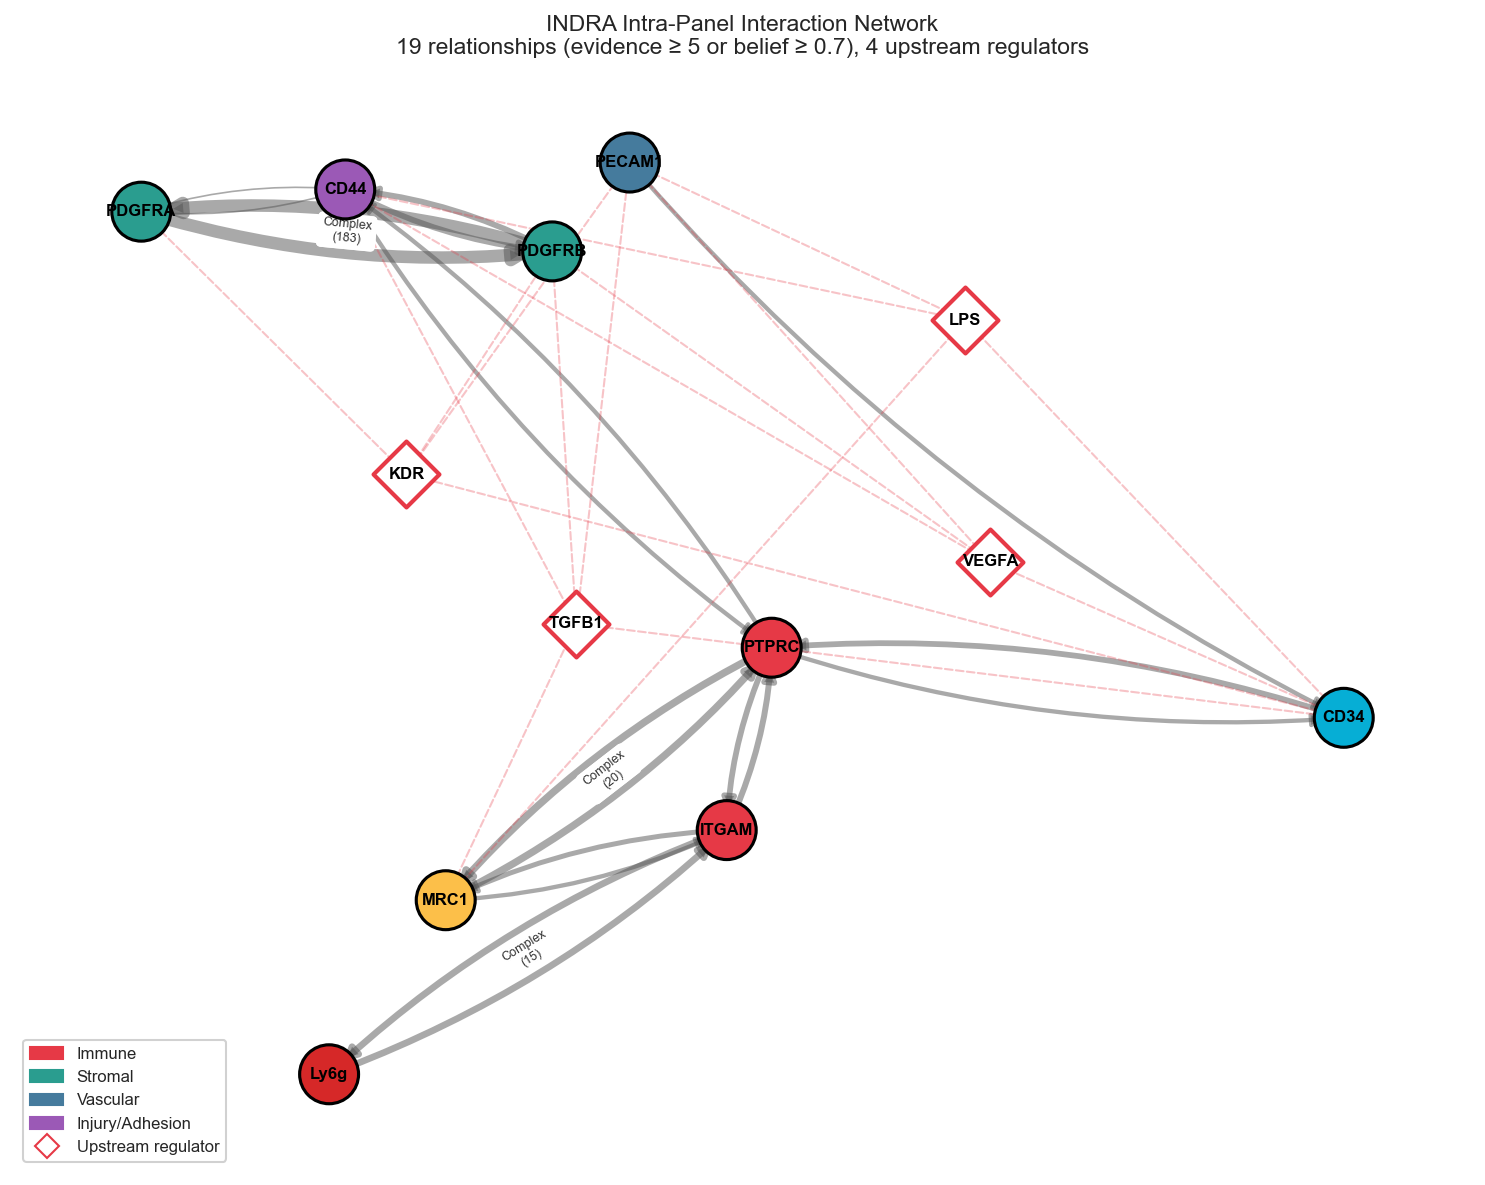

In [3]:
# --- 1b. Panel interaction network ---
stmts = indra_ctx['indra_statements']
regs = indra_ctx['shared_upstream_regulators']

G = nx.DiGraph()

# Add panel gene nodes
panel_genes = set()
for m in markers:
    gene = mg.get(m, {}).get('gene_name', m)
    if gene and gene != '-':
        panel_genes.add(gene)
        G.add_node(gene, node_type='panel')

# Add intra-panel edges (filter: evidence >= 5 or belief >= 0.7)
edge_types = {}
for s in stmts:
    if s['evidence'] >= 5 or s['belief'] >= 0.7:
        key = (s['source'], s['target'])
        if key not in edge_types or s['evidence'] > edge_types[key]['evidence']:
            edge_types[key] = s

for (src, tgt), s in edge_types.items():
    G.add_edge(src, tgt, weight=np.log2(s['evidence'] + 1),
               evidence=s['evidence'], stmt_type=s['type'],
               belief=s['belief'])

# Add top upstream regulators as external nodes
for reg_name, reg_info in regs.items():
    if reg_name not in panel_genes and reg_info['count'] >= 4:
        G.add_node(reg_name, node_type='regulator')
        for tgt in reg_info['targets']:
            if tgt in panel_genes:
                G.add_edge(reg_name, tgt, weight=1.5, evidence=0,
                           stmt_type='Regulation', belief=0.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

pos = nx.spring_layout(G, k=2.5, seed=42, iterations=80)

# Draw edges
panel_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) > 0]
reg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) == 0]
panel_widths = [G[u][v]['weight'] * 0.8 for u, v in panel_edges]

nx.draw_networkx_edges(G, pos, edgelist=panel_edges, width=panel_widths,
                       alpha=0.5, edge_color='#555', arrows=True,
                       arrowsize=12, ax=ax, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edges(G, pos, edgelist=reg_edges, width=1.0,
                       alpha=0.3, edge_color='#E63946', style='dashed',
                       arrows=True, arrowsize=10, ax=ax)

# Draw nodes
panel_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'panel']
reg_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'regulator']

panel_node_colors = [GENE_AXIS_COLOR.get(n, '#999') for n in panel_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=panel_nodes, node_color=panel_node_colors,
                       node_size=800, edgecolors='black', linewidths=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=reg_nodes, node_color='white',
                       node_size=500, edgecolors='#E63946', linewidths=2,
                       node_shape='D', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Edge labels for top interactions
top_edges = sorted(panel_edges, key=lambda e: G[e[0]][e[1]]['evidence'], reverse=True)[:5]
edge_labels = {(u, v): f"{G[u][v]['stmt_type']}\n({G[u][v]['evidence']})"
               for u, v in top_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6,
                             font_color='#333', ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#E63946', label='Immune'),
    mpatches.Patch(color='#2A9D8F', label='Stromal'),
    mpatches.Patch(color='#457B9D', label='Vascular'),
    mpatches.Patch(color='#9B59B6', label='Injury/Adhesion'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
               markeredgecolor='#E63946', markersize=8, label='Upstream regulator'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title('INDRA Intra-Panel Interaction Network\n'
             f'{len(panel_edges)} relationships (evidence \u2265 5 or belief \u2265 0.7), '
             f'{len(reg_nodes)} upstream regulators',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 2. Tissue Landscape

We annotate tissue with two complementary systems: **discrete boolean gating** (15 cell types via marker positivity rules) and **continuous multi-label memberships** (3-axis lineage/subtype/activation decomposition).

The tissue decomposes into three fractions (mouse-mean across the 8-mouse cohort, lineage threshold = 0.3):
- **~30% single-lineage** — superpixels scoring on exactly one lineage axis (subset of which is named by the boolean gates)
- **~48% multi-lineage interfaces** — superpixels scoring on 2+ lineages simultaneously
- **~22% no-lineage** — tubular epithelium, invisible to our 9-marker panel

These percentages are pulled from `results/biological_analysis/temporal_interfaces/interface_fractions.parquet` (run by `run_temporal_interface_analysis.py` per `analysis_plans/temporal_interfaces_plan.md`). Per-mouse and per-timepoint trajectories with effect sizes are in the companion notebook `notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb` (Part 2 and Part 2.5).

All discrete proportions below use **total superpixel count** as denominator (including unassigned).


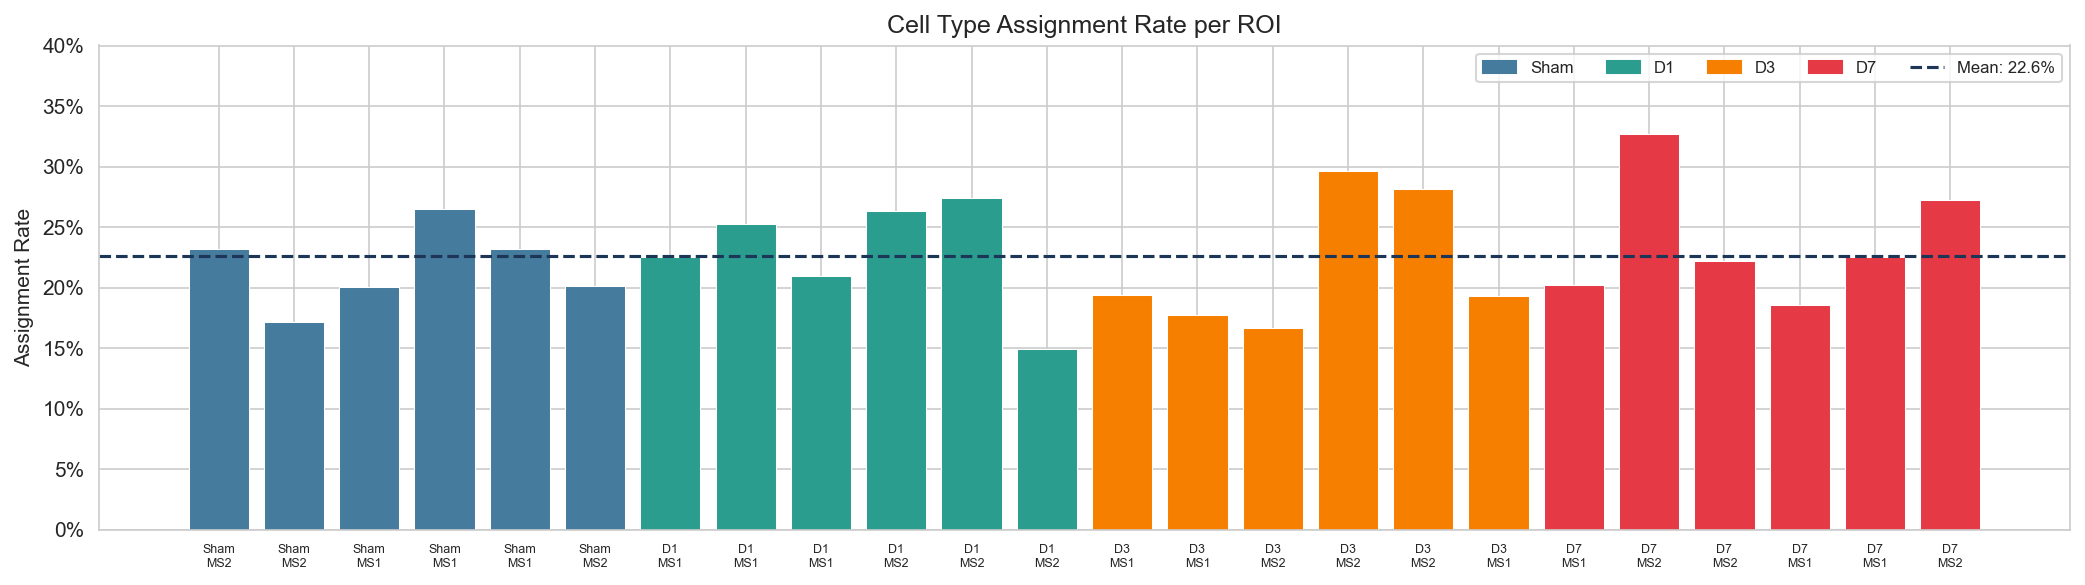

Assignment rate: 14.9% – 32.6% (mean 22.6%)


In [4]:
# --- 2a. Assignment rates by ROI ---
roi_sorted = roi_abundances.sort_values('timepoint')

fig, ax = plt.subplots(figsize=(14, 4))
colors = [TP_COLORS.get(tp, '#999') for tp in roi_sorted['timepoint']]
bars = ax.bar(range(len(roi_sorted)), roi_sorted['assignment_rate'], color=colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(roi_sorted['assignment_rate'].mean(), color='#1D3557', linestyle='--',
           linewidth=1.5, label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}')
ax.set_xticks(range(len(roi_sorted)))
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in roi_sorted.iterrows()],
                    fontsize=6, rotation=0)
ax.set_ylabel('Assignment Rate')
ax.set_title('Cell Type Assignment Rate per ROI')
ax.set_ylim(0, 0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
handles.append(plt.Line2D([0], [0], color='#1D3557', linestyle='--',
               label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}'))
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

print(f'Assignment rate: {roi_sorted["assignment_rate"].min():.1%} \u2013 '
      f'{roi_sorted["assignment_rate"].max():.1%} '
      f'(mean {roi_sorted["assignment_rate"].mean():.1%})')

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_67580/1692925960.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


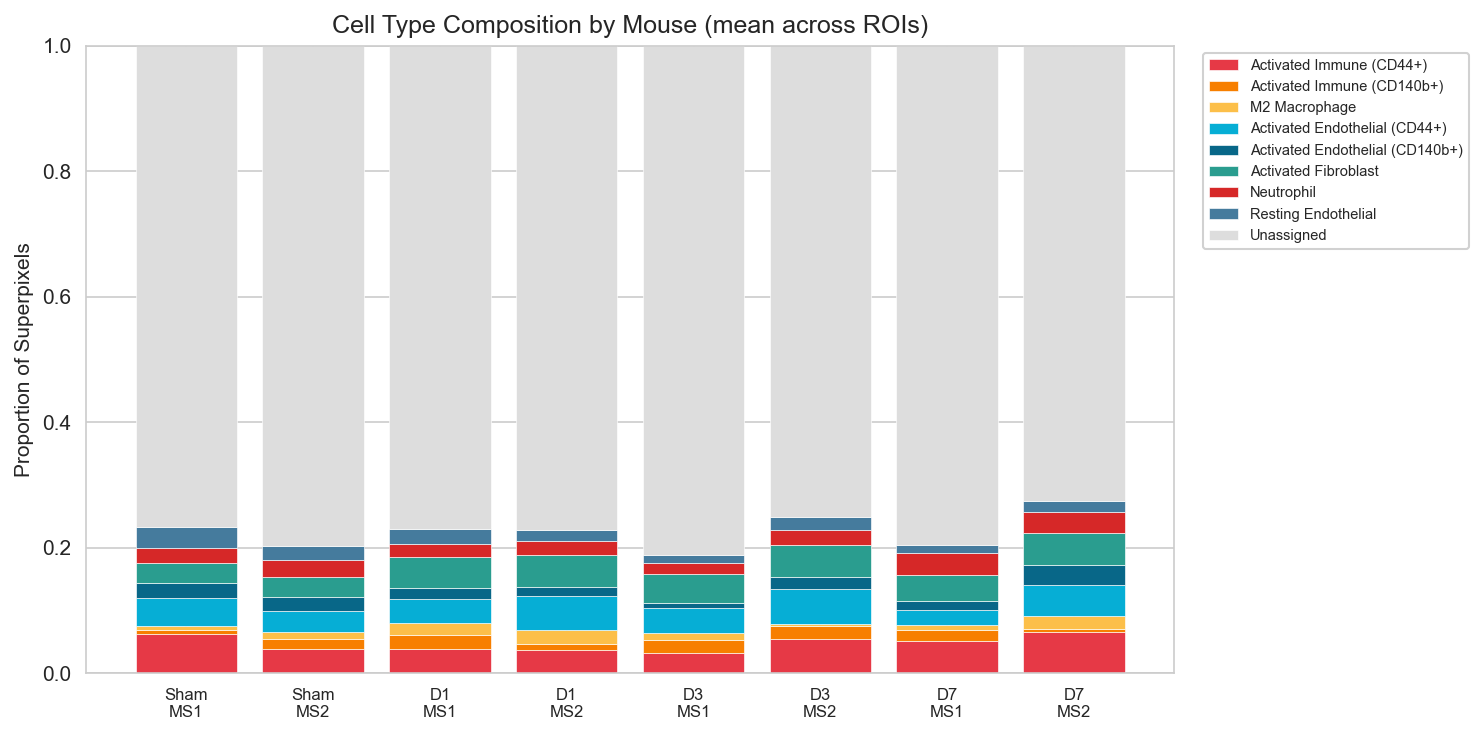

In [5]:
# --- 2b. Cell type composition at mouse level ---
prop_cols = [f'{ct}_prop' for ct in CT_ORDER]
existing_prop_cols = [c for c in prop_cols if c in roi_abundances.columns]
existing_cts = [c.replace('_prop', '') for c in existing_prop_cols]

mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
mouse_agg = mouse_agg.sort_values(['timepoint', 'mouse'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mouse_agg))
bottom = np.zeros(len(mouse_agg))

for ct, col in zip(existing_cts, existing_prop_cols):
    vals = mouse_agg[col].values
    ax.bar(x, vals, bottom=bottom, color=CT_COLORS.get(ct, '#999'),
           label=ct_label(ct), edgecolor='white', linewidth=0.3)
    bottom += vals

# Unassigned on top
unassigned = 1.0 - bottom
ax.bar(x, np.maximum(unassigned, 0), bottom=bottom, color='#DDDDDD',
       label='Unassigned', edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in mouse_agg.iterrows()],
                    fontsize=8)
ax.set_ylabel('Proportion of Superpixels')
ax.set_title('Cell Type Composition by Mouse (mean across ROIs)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, framealpha=0.9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_67580/1519973823.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


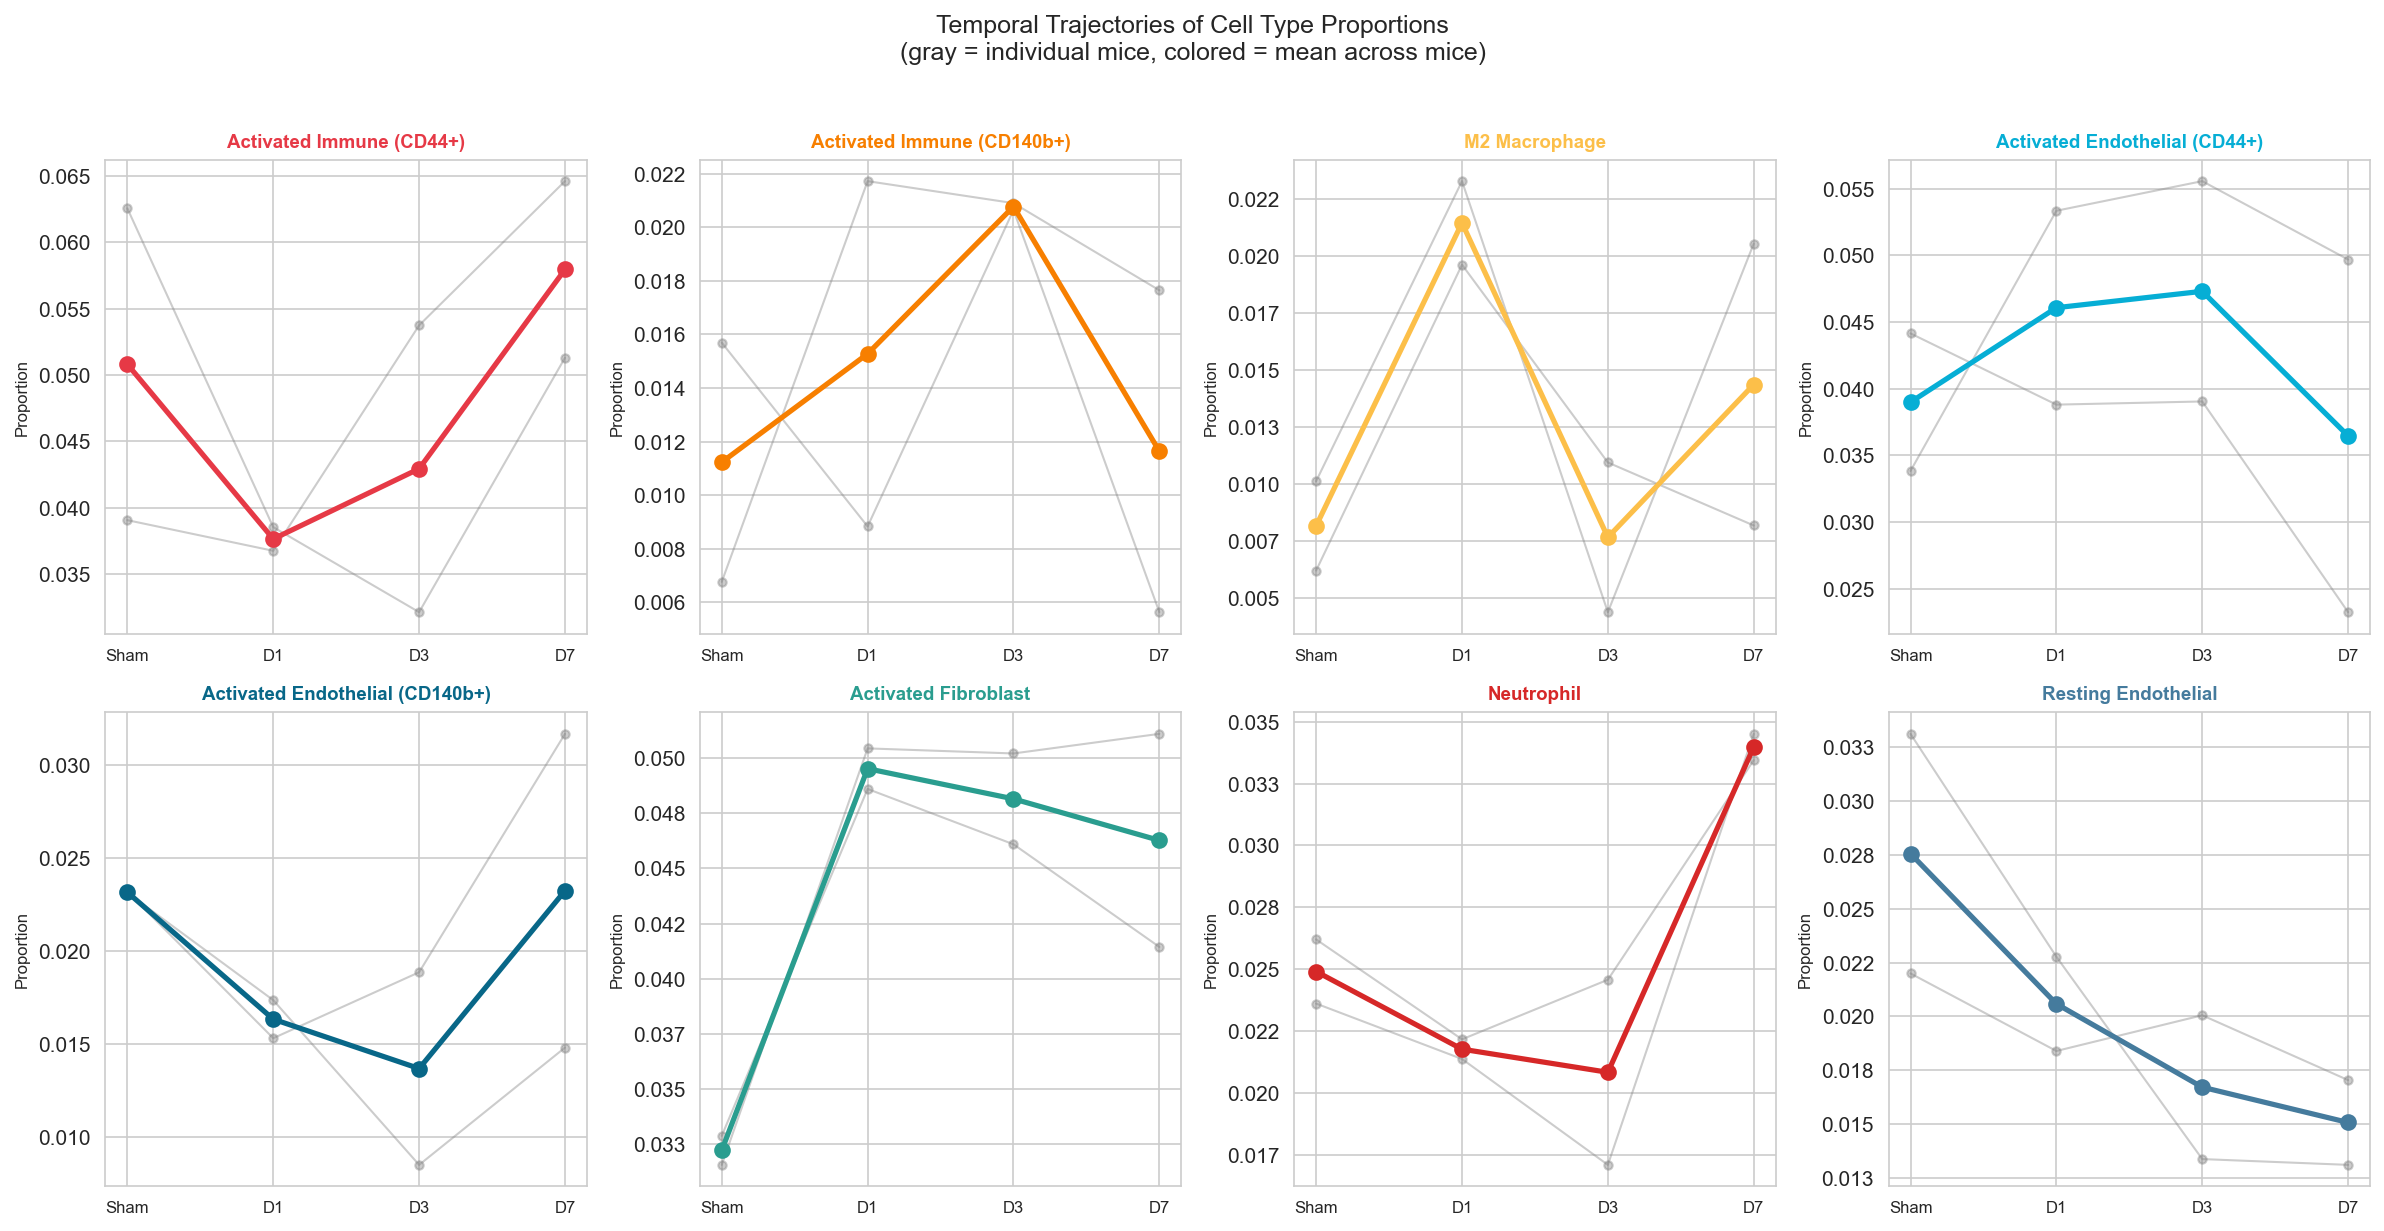

In [6]:
# --- 2c. Temporal trajectories per cell type ---
mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg_tp['timepoint'] = pd.Categorical(mouse_agg_tp['timepoint'], categories=TP_ORDER, ordered=True)

n_cts = len(existing_cts)
ncols = 4
nrows = (n_cts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, (ct, col) in enumerate(zip(existing_cts, existing_prop_cols)):
    ax = axes[i]
    tp_means = mouse_agg_tp.groupby('timepoint', observed=True)[col].mean()

    # Individual mice as thin lines
    for mouse, grp in mouse_agg_tp.groupby('mouse'):
        grp_sorted = grp.sort_values('timepoint')
        tp_idx = [TP_ORDER.index(tp) for tp in grp_sorted['timepoint']]
        ax.plot(tp_idx, grp_sorted[col].values, 'o-', color='gray',
                alpha=0.4, linewidth=1, markersize=4)

    # Mean line
    mean_vals = [tp_means.get(tp, np.nan) for tp in TP_ORDER]
    ax.plot(range(len(TP_ORDER)), mean_vals, 'o-',
            color=CT_COLORS.get(ct, '#1D3557'), linewidth=2.5, markersize=7, zorder=5)

    ax.set_xticks(range(len(TP_ORDER)))
    ax.set_xticklabels(TP_ORDER, fontsize=8)
    ax.set_title(ct_label(ct), fontsize=9, fontweight='bold',
                 color=CT_COLORS.get(ct, '#333'))
    ax.set_ylabel('Proportion', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Temporal Trajectories of Cell Type Proportions\n'
             '(gray = individual mice, colored = mean across mice)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Continuous Lineage Composition and Multi-Lineage Interactions

The temporal trajectories above capture only the ~24% of tissue that boolean gates assign to specific cell types. What about the other ~76%?

The continuous membership system scores every superpixel on three independent axes:
- **Lineage** (immune / endothelial / stromal) — non-exclusive, sigmoid-normalized [0,1]
- **Subtype** (neutrophil, M2, myeloid, non-myeloid) — within-lineage refinement
- **Activation** (CD44, CD140b) — independent overlay across all lineages

Most "unassigned" superpixels are interface tissue (multi-lineage); only the ~22% no-lineage fraction falls outside the 9-marker panel's reach.

**Pre-registered temporal interface analysis** (run by `run_temporal_interface_analysis.py` per `analysis_plans/temporal_interfaces_plan.md`) computes:
- Family A: mouse-level interface composition shifts on the CLR-transformed 8-component compositional vector
- Family B: continuous neighborhood lineage shifts (`neighbor_lineage_X − self_lineage_X`) per (cell type × lineage), trajectory-filtered
- Family C: cross-compartment CD44+ activation rates against a Sham-reference 75th-percentile threshold

Spatial visualization, per-cell-type heatmaps, mouse-level dot plots, and join-count spatial coherence statistics are in `notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb` Parts 2 and 2.5. For quantification of information lost by boolean discretization, see `notebooks/methods_validation/01_technical_methods/gradient_discretization.ipynb`.


In [ ]:
# --- 2d. Lineage composition and interface fraction ---
lineage_cols = [c for c in roi_abundances.columns if c.startswith('lineage_') and c.endswith('_mean')]

if lineage_cols and 'mixed_fraction' in roi_abundances.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Panel A: Mean lineage scores by timepoint
    mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[lineage_cols].mean().reset_index()
    mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
    mouse_mean = mouse_agg.groupby('timepoint')[lineage_cols].mean()
    
    x = np.arange(len(mouse_mean))
    width = 0.25
    lineage_colors = {'lineage_immune_mean': '#E63946', 'lineage_endothelial_mean': '#457B9D', 'lineage_stromal_mean': '#8AB17D'}
    
    for i, col in enumerate(lineage_cols):
        label = col.replace('lineage_', '').replace('_mean', '').capitalize()
        color = lineage_colors.get(col, f'C{i}')
        ax1.bar(x + i * width - width, mouse_mean[col].values, width,
                label=label, color=color, alpha=0.85, edgecolor='white')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(mouse_mean.index, fontsize=10)
    ax1.set_ylabel('Mean Lineage Score')
    ax1.set_title('A. Lineage Signal by Timepoint', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel B: Multi-lineage fraction trend
    mouse_mixed = roi_abundances.groupby(['timepoint', 'mouse'])['mixed_fraction'].mean().reset_index()
    mouse_mixed['timepoint'] = pd.Categorical(mouse_mixed['timepoint'], categories=TP_ORDER, ordered=True)
    
    for tp_idx, tp in enumerate(TP_ORDER):
        vals = mouse_mixed[mouse_mixed['timepoint'] == tp]['mixed_fraction'] * 100
        color = TP_COLORS.get(tp, '#999')
        ax2.bar(tp_idx, vals.mean(), yerr=vals.std() if len(vals) > 1 else 0,
                color=color, capsize=4, alpha=0.85, edgecolor='white')
    
    ax2.set_xticks(range(len(TP_ORDER)))
    ax2.set_xticklabels(TP_ORDER, fontsize=10)
    ax2.set_ylabel('% Multi-Lineage Superpixels')
    ax2.set_title('B. Tissue Interface Fraction', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    fig.suptitle('Continuous Lineage Membership', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print("Lineage columns not found in roi_abundances — re-run differential_abundance_analysis.py")

### Reading the Lineage Landscape

**Panel A** shows mean lineage scores remain relatively stable across timepoints — this is expected because per-ROI sigmoid normalization compresses temporal dynamics (a documented caveat). The effect sizes in Section 3d below (lineage-level Hedges' g) capture the attenuated but still informative temporal shifts.

**Panel B** shows the multi-lineage interface fraction is remarkably consistent across timepoints, suggesting tissue interface architecture is a structural feature of kidney tissue, not an injury artifact. The *composition* of interfaces (which lineage combinations dominate at each timepoint) is explored in the companion spatial analysis notebook (Part 2 mouse-level dot plot, Part 2.5 continuous neighborhood heatmap).


---
## 3. Differential Abundance (Tier 3 — context, not direct evidence for the candidate finding)

This section reports cell-type proportion changes via mouse-level Hedges' g effect sizes. **It is Tier 3 context for the redistribution candidate finding** — different analysis, different endpoints, different families. The candidate finding lives in the temporal interface analysis (Family A CLR + Family C compartment, Section 6 below). Section 3 is descriptive characterization of the same dataset through a different lens.

**Statistical realities at n=2:**
- Mann-Whitney U can only produce p-values of ~0.33, 0.67, or 1.0 (two-sided)
- No comparison can reach p < 0.05 regardless of effect magnitude
- Bootstrap range carries only ~9 unique Hedges' g values (NOT a coverage-bearing CI)
- Zero FDR-significant findings — this is the honest answer; no FDR proxies are used after Gate 6.

Effect sizes and ranges are provided for **follow-up study design**, not for confirmatory claims.


In [ ]:
# --- 3a. Forest plot: Hedges' g with bootstrap ranges ---
comparisons = temporal_da['comparison'].unique()
comp_colors = dict(zip(comparisons, sns.color_palette('Set2', len(comparisons))))

# Sort: group by cell type, within each by |hedges_g|
temporal_da['abs_g'] = temporal_da['hedges_g'].abs()
plot_df = temporal_da.sort_values(['cell_type', 'abs_g'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(10, 12))
y_positions = []
y_labels = []
y = 0
prev_ct = None

for _, row in plot_df.iterrows():
    ct = row['cell_type']
    if ct != prev_ct and prev_ct is not None:
        y += 0.5  # gap between cell types
    prev_ct = ct

    color = comp_colors[row['comparison']]
    ci_lo = row['ci_lower_95'] if not np.isnan(row['ci_lower_95']) else row['hedges_g'] - 1
    ci_hi = row['ci_upper_95'] if not np.isnan(row['ci_upper_95']) else row['hedges_g'] + 1

    # Clip extreme CIs for readability
    ci_lo_plot = max(ci_lo, -20)
    ci_hi_plot = min(ci_hi, 20)

    ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
    ax.plot(row['hedges_g'], y, 'o', color=color, markersize=5, zorder=5)

    # q-value annotation
    q_text = f"q={row['p_value_fdr']:.2f}" if not np.isnan(row['p_value_fdr']) else 'q=NA'
    ax.text(20.5, y, q_text, fontsize=5.5, va='center', color='#666')

    y_positions.append(y)
    y_labels.append(f"{ct_label(ct)} | {row['comparison']}")
    y += 1

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel('Hedges\' g (effect size)', fontsize=10)
ax.set_title('Temporal Differential Abundance: Effect Sizes with Bootstrap Ranges\n'
             '(all q > 0.05 after BH FDR correction)', fontsize=11)
ax.set_xlim(-22, 22)
ax.invert_yaxis()

legend_handles = [mpatches.Patch(color=c, label=comp) for comp, c in comp_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7, title='Comparison')
plt.tight_layout()
plt.show()

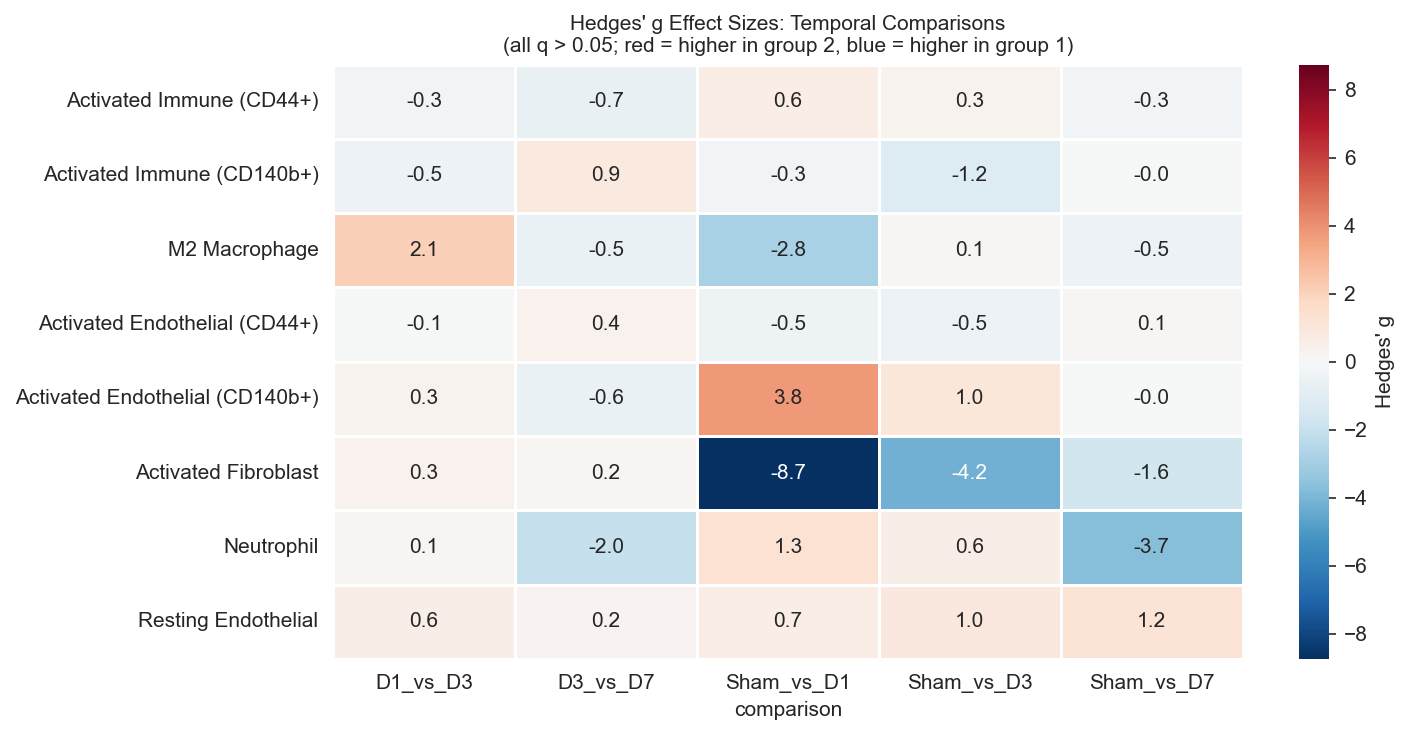

In [8]:
# --- 3b. Effect size heatmap ---
pivot = temporal_da.pivot_table(index='cell_type', columns='comparison',
                                values='hedges_g', aggfunc='first')
# Reorder
pivot = pivot.reindex(index=[ct for ct in CT_ORDER if ct in pivot.index])
pivot_labels = pivot.rename(index=ct_label)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = min(abs(pivot.values[np.isfinite(pivot.values)]).max(), 10)
sns.heatmap(pivot_labels, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': "Hedges' g"}, ax=ax)
ax.set_title("Hedges' g Effect Sizes: Temporal Comparisons\n"
             "(all q > 0.05; red = higher in group 2, blue = higher in group 1)",
             fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

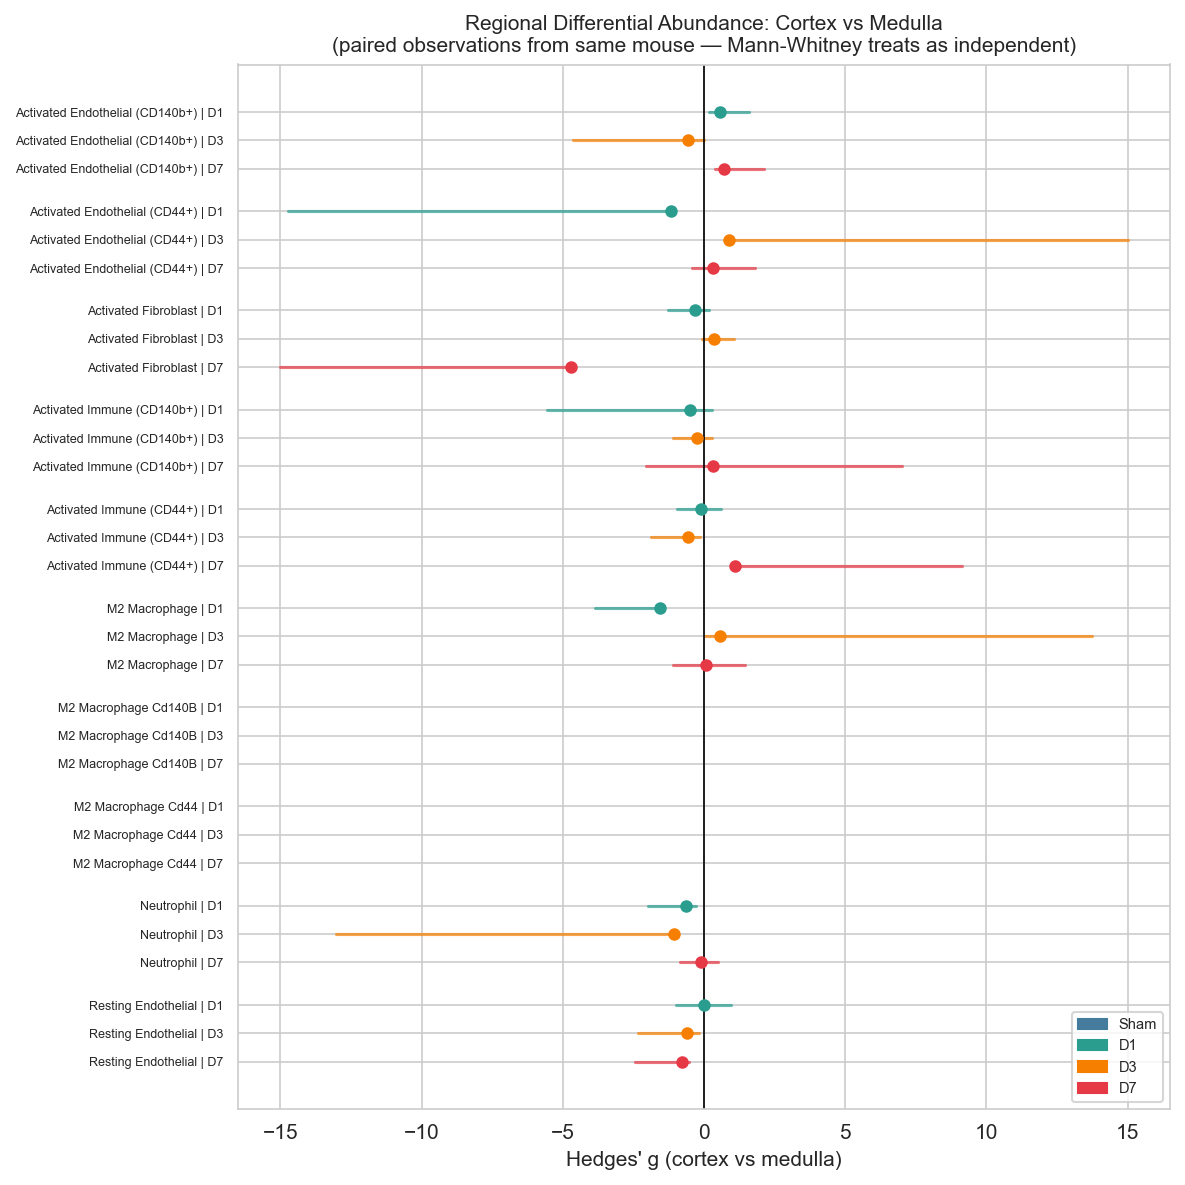

In [9]:
# --- 3c. Regional comparison (cortex vs medulla) ---
if len(regional_da) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    regional_da_sorted = regional_da.sort_values(['cell_type', 'timepoint'])

    y = 0
    y_positions = []
    y_labels = []
    prev_ct = None

    for _, row in regional_da_sorted.iterrows():
        ct = row['cell_type']
        if ct != prev_ct and prev_ct is not None:
            y += 0.5
        prev_ct = ct

        tp = row['timepoint']
        color = TP_COLORS.get(tp, '#999')
        g = row['hedges_g']
        ci_lo = row.get('ci_lower_95', g - 1)
        ci_hi = row.get('ci_upper_95', g + 1)
        if pd.isna(ci_lo): ci_lo = g - 1
        if pd.isna(ci_hi): ci_hi = g + 1

        ci_lo_plot = max(ci_lo, -15)
        ci_hi_plot = min(ci_hi, 15)

        ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
        ax.plot(g, y, 'o', color=color, markersize=5, zorder=5)

        y_positions.append(y)
        y_labels.append(f'{ct_label(ct)} | {tp}')
        y += 1

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel("Hedges' g (cortex vs medulla)", fontsize=10)
    ax.set_title('Regional Differential Abundance: Cortex vs Medulla\n'
                 '(paired observations from same mouse \u2014 Mann-Whitney treats as independent)',
                 fontsize=10)
    ax.invert_yaxis()

    handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
    ax.legend(handles=handles, loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('No regional DA results available.')

In [ ]:
# --- 3d. Lineage-level effect sizes ---
lineage_da = temporal_da[temporal_da['cell_type'].str.startswith('lineage:')]

if len(lineage_da) > 0:
    print("Lineage-Level Temporal Effect Sizes (Hedges' g):\n")
    display_cols = ['cell_type', 'comparison', 'mean_1', 'mean_2', 'hedges_g', 'p_value_fdr']
    lineage_sorted = lineage_da.sort_values('hedges_g', key=abs, ascending=False)
    print(lineage_sorted[display_cols].to_string(index=False, float_format='%.3f'))
    
    print("\nNote: Lineage means are per-ROI sigmoid-normalized scores. Per-ROI normalization")
    print("compresses temporal dynamics — effect sizes here are attenuated relative to discrete types.")
else:
    print("No lineage-level DA rows found — re-run differential_abundance_analysis.py")

---
## 4. Spatial Neighborhood Architecture (Tier 3 — context, not direct evidence for the candidate finding)

This section reports discrete neighborhood enrichment per cell-type pair via permutation testing. **Tier 3 context** relative to the candidate finding: it characterizes spatial co-localization at the discrete cell-type level, while the candidate finding operates on continuous lineage scores (Family A) and raw-marker compartments (Family C).

For each focal cell type, we compute the proportion of its k=10 nearest neighbors belonging to each other type, then compare to a permutation null (1,000 global shuffles of cell type labels within each ROI, Phipson & Smyth pseudocount).

**Self-enrichment caveat**: cell types defined by overlapping markers (e.g., activated_myeloid_cd44 and activated_endothelial_cd44 both require CD44+) share expression space and thus physical space. Self-enrichment (diagonal) reflects both genuine spatial clustering AND marker-sharing circularity.


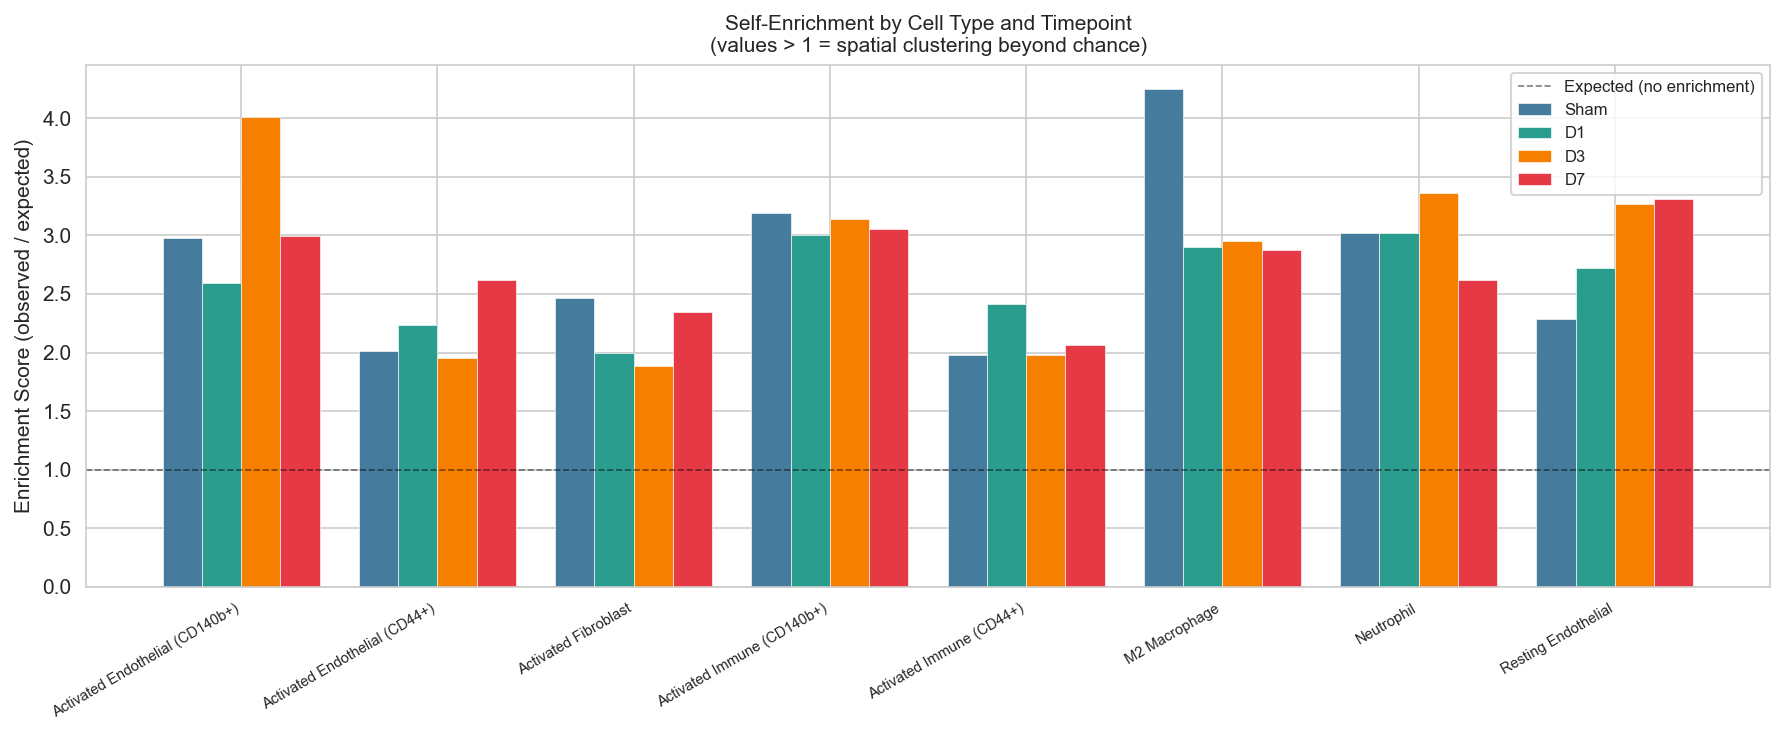

Self-enrichment range: 1.88x – 4.25x (all cell types cluster with themselves)


In [10]:
# --- 4a. Self-enrichment temporal dynamics ---
self_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] == temporal_enrich['neighbor_cell_type']
].copy()
self_enrich['timepoint'] = pd.Categorical(self_enrich['timepoint'],
                                          categories=TP_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 5))
ct_list = sorted(self_enrich['focal_cell_type'].unique())
x = np.arange(len(ct_list))
width = 0.2

for i, tp in enumerate(TP_ORDER):
    tp_data = self_enrich[self_enrich['timepoint'] == tp]
    vals = [tp_data[tp_data['focal_cell_type'] == ct]['enrichment_score'].values[0]
            if len(tp_data[tp_data['focal_cell_type'] == ct]) > 0 else 0
            for ct in ct_list]
    bars = ax.bar(x + i * width, vals, width, color=TP_COLORS[tp],
                  label=tp, edgecolor='white', linewidth=0.3)

ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
           label='Expected (no enrichment)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([ct_label(ct) for ct in ct_list], fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Enrichment Score (observed / expected)')
ax.set_title('Self-Enrichment by Cell Type and Timepoint\n'
             '(values > 1 = spatial clustering beyond chance)', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Self-enrichment range: {self_enrich["enrichment_score"].min():.2f}x \u2013 '
      f'{self_enrich["enrichment_score"].max():.2f}x '
      f'(all cell types cluster with themselves)')

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_67580/1770094215.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


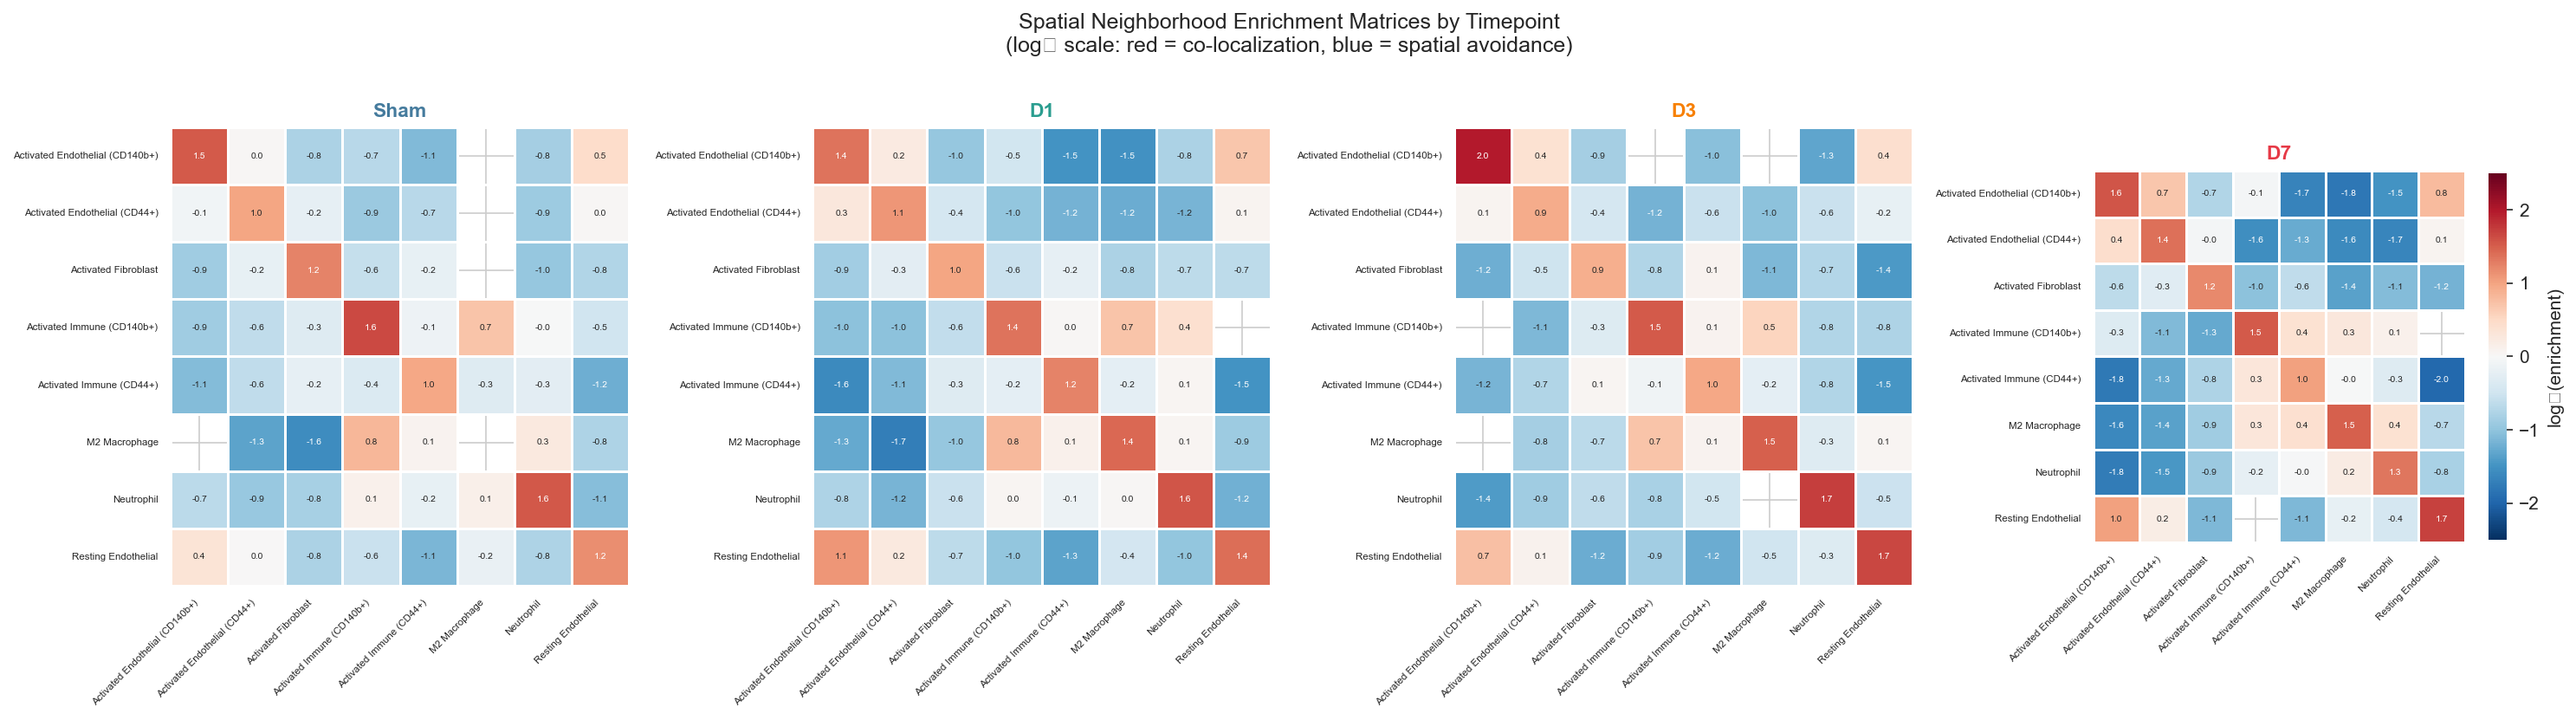

In [11]:
# --- 4b. Full enrichment matrices by timepoint ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_cts = sorted(temporal_enrich['focal_cell_type'].unique())
ct_short = [ct_label(ct) for ct in all_cts]

for idx, tp in enumerate(TP_ORDER):
    ax = axes[idx]
    tp_data = temporal_enrich[temporal_enrich['timepoint'] == tp]

    matrix = pd.DataFrame(np.nan, index=all_cts, columns=all_cts)
    for _, row in tp_data.iterrows():
        matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']

    matrix_display = matrix.copy()
    matrix_display.index = ct_short
    matrix_display.columns = ct_short

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == 3,
                cbar_kws={'label': 'log\u2082(enrichment)', 'shrink': 0.8} if idx == 3 else {},
                ax=ax, annot_kws={'fontsize': 5})
    ax.set_title(tp, fontsize=11, fontweight='bold', color=TP_COLORS[tp])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=5.5, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=5.5)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment Matrices by Timepoint\n'
             '(log\u2082 scale: red = co-localization, blue = spatial avoidance)',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

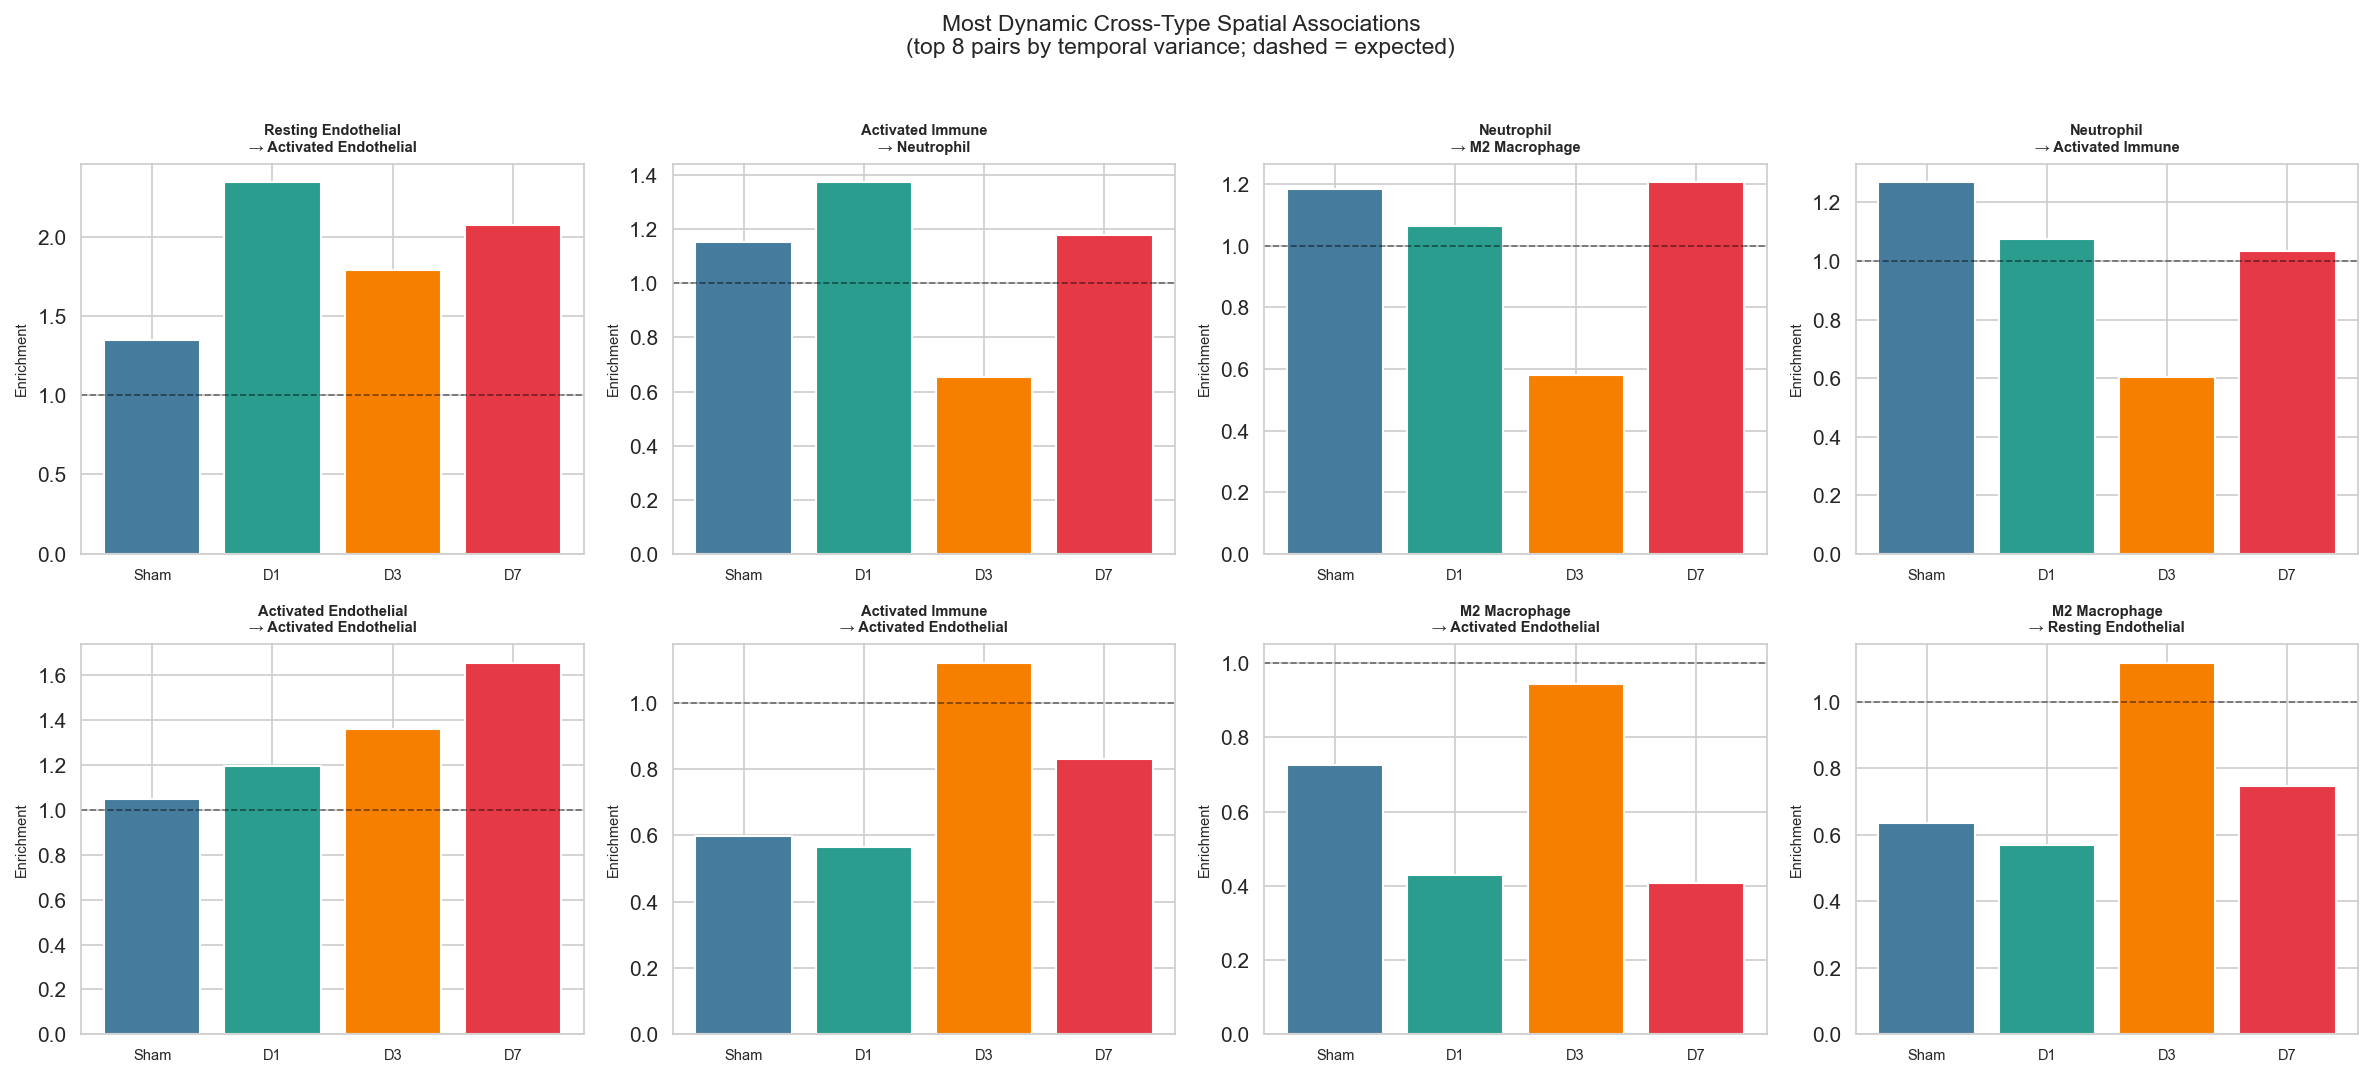

In [12]:
# --- 4c. Key temporal dynamics of cross-type pairs ---
cross_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] != temporal_enrich['neighbor_cell_type']
].copy()

# Find most dynamic pairs (largest temporal variance)
pair_var = cross_enrich.groupby(
    ['focal_cell_type', 'neighbor_cell_type']
)['enrichment_score'].var().reset_index()
pair_var.columns = ['focal', 'neighbor', 'variance']
top_pairs = pair_var.nlargest(8, 'variance')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (_, pair) in enumerate(top_pairs.iterrows()):
    ax = axes[i]
    mask = ((cross_enrich['focal_cell_type'] == pair['focal']) &
            (cross_enrich['neighbor_cell_type'] == pair['neighbor']))
    pair_data = cross_enrich[mask].sort_values('timepoint')

    for _, row in pair_data.iterrows():
        tp = row['timepoint']
        ax.bar(TP_ORDER.index(tp), row['enrichment_score'],
               color=TP_COLORS.get(tp, '#999'), edgecolor='white')

    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(TP_ORDER, fontsize=7)
    focal_short = ct_label(pair['focal']).split('(')[0].strip()
    neighbor_short = ct_label(pair['neighbor']).split('(')[0].strip()
    ax.set_title(f'{focal_short}\n\u2192 {neighbor_short}',
                 fontsize=7, fontweight='bold')
    ax.set_ylabel('Enrichment', fontsize=7)

fig.suptitle('Most Dynamic Cross-Type Spatial Associations\n'
             '(top 8 pairs by temporal variance; dashed = expected)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


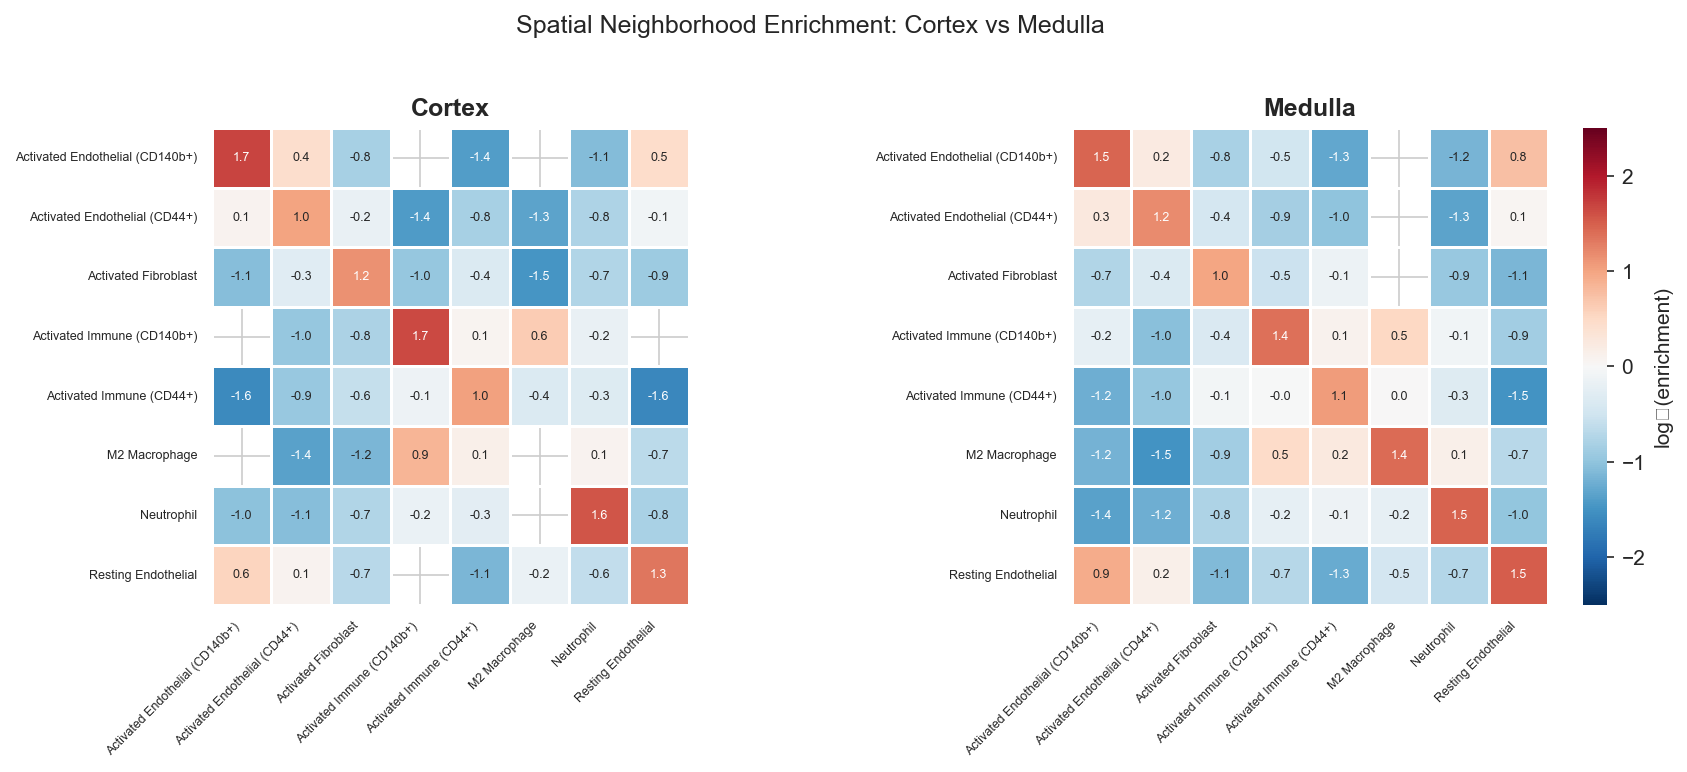

In [13]:
# --- 4d. Regional enrichment comparison ---
regions = sorted(regional_enrich['region'].unique())
all_cts_r = sorted(regional_enrich['focal_cell_type'].unique())
ct_short_r = [ct_label(ct) for ct in all_cts_r]

n_regions = len(regions)
fig, axes = plt.subplots(1, n_regions, figsize=(6 * n_regions, 5))
if n_regions == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    reg_data = regional_enrich[regional_enrich['region'] == region]

    matrix = pd.DataFrame(np.nan, index=all_cts_r, columns=all_cts_r)
    for _, row in reg_data.iterrows():
        if 'log2_enrichment' in row:
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']
        else:
            val = np.log2(row['enrichment_score']) if row['enrichment_score'] > 0 else np.nan
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = val

    matrix_display = matrix.copy()
    matrix_display.index = ct_short_r
    matrix_display.columns = ct_short_r

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == n_regions - 1,
                cbar_kws={'label': 'log\u2082(enrichment)'} if idx == n_regions - 1 else {},
                ax=ax, annot_kws={'fontsize': 6})
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment: Cortex vs Medulla',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Knowledge Graph Integration (Tier 3 — context, not validation of the candidate finding)

The INDRA/CoGEx knowledge graph provides **biological context** for the panel design and for interpretation of effect sizes. It is **not validation** of the candidate finding. 117 intra-panel causal relationships (queried 2026-02-26) connect the 8 groundable panel genes through known molecular mechanisms documented in the literature.

**Circularity caveat**: For cell types defined by marker co-expression (e.g., neutrophil = CD45+/Ly6G+), INDRA relationships between those same markers (e.g., ITGAM–Ly6G Complex) trivially "explain" self-enrichment. This is tautological, not confirmatory. INDRA context is most informative for **cross-type** spatial associations where the markers involved are from different biological axes.


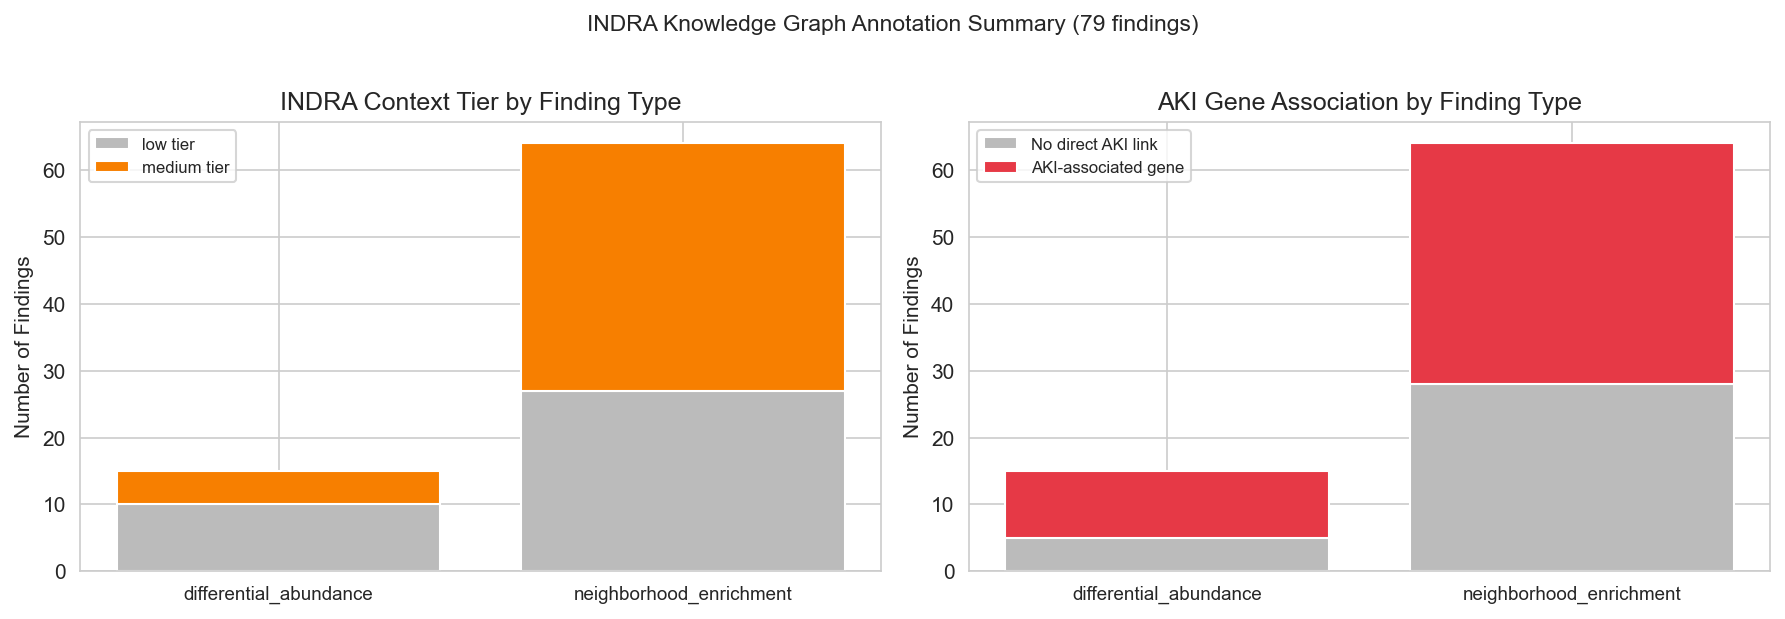

Total annotated findings: 79
  Medium-tier INDRA context: 42
  Low-tier INDRA context: 37
  AKI gene association: 46


In [14]:
# --- 5a. Finding annotation summary ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By finding type and INDRA tier
ax = axes[0]
tier_counts = indra_annot.groupby(['finding_type', 'indra_context_tier']).size().unstack(fill_value=0)
tier_colors = {'medium': '#F77F00', 'low': '#BBBBBB', 'high': '#E63946'}
bottom = np.zeros(len(tier_counts))
for tier in ['low', 'medium', 'high']:
    if tier in tier_counts.columns:
        vals = tier_counts[tier].values
        ax.bar(range(len(tier_counts)), vals, bottom=bottom,
               color=tier_colors.get(tier, '#999'), label=f'{tier} tier',
               edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(tier_counts)))
ax.set_xticklabels(tier_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('INDRA Context Tier by Finding Type')
ax.legend(fontsize=8)

# AKI gene association
ax = axes[1]
aki_counts = indra_annot.groupby(['finding_type', 'aki_gene_association']).size().unstack(fill_value=0)
aki_colors = {True: '#E63946', False: '#BBBBBB'}
bottom = np.zeros(len(aki_counts))
for has_aki in [False, True]:
    if has_aki in aki_counts.columns:
        vals = aki_counts[has_aki].values
        label = 'AKI-associated gene' if has_aki else 'No direct AKI link'
        ax.bar(range(len(aki_counts)), vals, bottom=bottom,
               color=aki_colors[has_aki], label=label, edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(aki_counts)))
ax.set_xticklabels(aki_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('AKI Gene Association by Finding Type')
ax.legend(fontsize=8)

plt.suptitle(f'INDRA Knowledge Graph Annotation Summary ({len(indra_annot)} findings)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total annotated findings: {len(indra_annot)}')
print(f'  Medium-tier INDRA context: {(indra_annot["indra_context_tier"] == "medium").sum()}')
print(f'  Low-tier INDRA context: {(indra_annot["indra_context_tier"] == "low").sum()}')
print(f'  AKI gene association: {indra_annot["aki_gene_association"].sum()}')

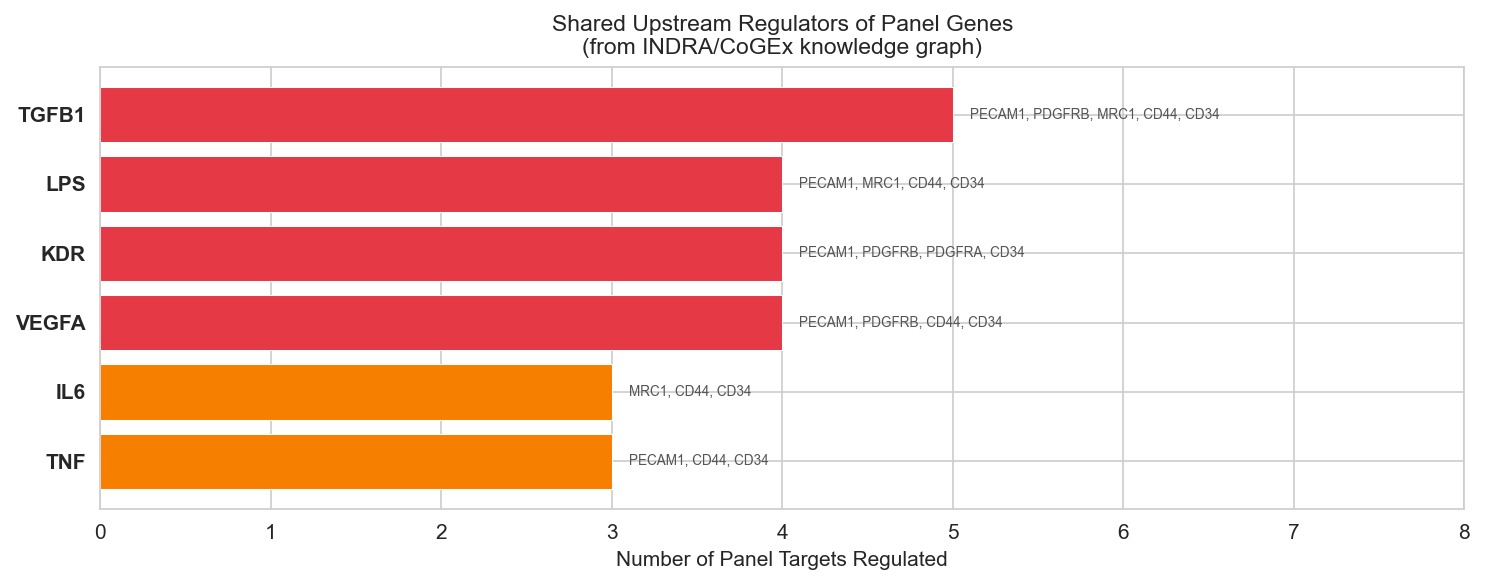

TGFB1: Master regulator of renal fibrosis. Regulates 5/8 panel genes spanning endothelial, stromal, immune, and injury axes.
LPS: Innate immune activation. Relevant to DAMP-mediated sterile inflammation in AKI.
KDR: VEGFR2 — connects VEGF signaling to endothelial and pericyte biology.
VEGFA: Vascular homeostasis and angiogenesis. Regulates both endothelial markers and injury/stromal markers.
IL6: Inflammatory cytokine; CD44 and MRC1 as targets connects injury to resolution.
TNF: Pro-inflammatory cytokine central to AKI pathogenesis.


In [15]:
# --- 5b. Upstream regulator analysis ---
regs = indra_ctx['shared_upstream_regulators']

reg_names = list(regs.keys())
reg_counts = [regs[r]['count'] for r in reg_names]
reg_relevance = [regs[r]['relevance'] for r in reg_names]

# Sort by count
order = np.argsort(reg_counts)[::-1]
reg_names = [reg_names[i] for i in order]
reg_counts = [reg_counts[i] for i in order]
reg_relevance = [reg_relevance[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
colors_reg = ['#E63946' if c >= 4 else '#F77F00' if c >= 3 else '#BBBBBB'
              for c in reg_counts]
bars = ax.barh(range(len(reg_names)), reg_counts, color=colors_reg,
               edgecolor='white', linewidth=0.5)

for i, (name, count) in enumerate(zip(reg_names, reg_counts)):
    targets = regs[name]['targets']
    target_str = ', '.join(targets)
    ax.text(count + 0.1, i, f'{target_str}', fontsize=6.5, va='center', color='#555')

ax.set_yticks(range(len(reg_names)))
ax.set_yticklabels(reg_names, fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Panel Targets Regulated')
ax.set_title('Shared Upstream Regulators of Panel Genes\n'
             '(from INDRA/CoGEx knowledge graph)', fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 8)
plt.tight_layout()
plt.show()

# Print relevance
for name, rel in zip(reg_names, reg_relevance):
    print(f'{name}: {rel}')

In [16]:
# --- 5c. Mechanistic narratives cross-referenced with spatial data ---
narratives = indra_ctx['mechanistic_narratives']

print('=== Mechanistic Narratives from INDRA Knowledge Graph ===')
print('(cross-referenced with observed spatial enrichment)\n')

for pair_key, narrative_text in narratives.items():
    # Parse pair key (e.g., 'endothelial_endothelial' or 'macrophage_fibroblast')
    parts = pair_key.split('_')
    mid = len(parts) // 2
    focal_key = '_'.join(parts[:mid])
    neighbor_key = '_'.join(parts[mid:])

    # Try to find matching enrichment data
    enrichment_info = ''
    for _, row in temporal_enrich.iterrows():
        if (focal_key in row['focal_cell_type'] and
            neighbor_key in row['neighbor_cell_type']):
            enrichment_info = (f"  Spatial enrichment at {row['timepoint']}: "
                              f"{row['enrichment_score']:.2f}x "
                              f"(log\u2082={row['log2_enrichment']:.2f})")
            break

    print(f'\u2500\u2500\u2500 {pair_key.replace("_", " ").title()} \u2500\u2500\u2500')
    # Wrap text at 100 chars
    words = narrative_text.split()
    line = ''
    for word in words:
        if len(line) + len(word) + 1 > 100:
            print(f'  {line}')
            line = word
        else:
            line = f'{line} {word}'.strip()
    if line:
        print(f'  {line}')
    if enrichment_info:
        print(enrichment_info)
    print()

=== Mechanistic Narratives from INDRA Knowledge Graph ===
(cross-referenced with observed spatial enrichment)

─── Endothelial Endothelial ───
  Endothelial self-clustering reflects vascular network topology. CD31+/CD34+ endothelial cells in the
  peritubular capillary plexus are physically connected. PECAM1 mediates homophilic adhesion
  (GO:0007156). Both share glomerular endothelium development (GO:0072011).
  Spatial enrichment at D1: 2.59x (log₂=1.35)

─── Fibroblast Fibroblast ───
  PDGFRA+ fibroblast clustering reflects interstitial compartment organization. PDGFRA is expressed in
  kidney cortex and nephron tubule interstitium. In nephrogenesis (WP4823), fibroblasts form the
  structural scaffold of the kidney.
  Spatial enrichment at D1: 1.99x (log₂=0.98)

─── Macrophage Macrophage ───
  Myeloid cell clustering reflects immune niche formation. ITGAM+ cells accumulate at sites of injury
  via complement-mediated adhesion. MRC1+ M2 macrophages (CL:0000890) cluster in resolution 

---
## 6. Synthesis & Forward Design

This pilot study demonstrates a workflow for knowledge-graph-guided spatial proteomics: IMC data processed through superpixel segmentation, dual annotation (discrete boolean gating + continuous multi-label memberships), and three pre-registered endpoint families (interface composition CLR, continuous neighborhood deltas, cross-compartment activation), with findings contextualized against INDRA/CoGEx causal relationships.

**Co-headline selection is post-hoc** (after Gate 6 normalization sensitivity revealed which endpoints survive changing normalization regimes). The co-headline filter itself was not pre-registered but is constrained by pre-registered sensitivity outputs: require direction-consistent between per-ROI and Sham-reference regimes at Sham→D7, per-ROI |g| > 0.5, and magnitude not collapsing by >80%. Of 8 Family A CLR Sham→D7 endpoints, 2 meet all three criteria; 3 sign-reverse; 1 magnitude-collapses; 2 are near-zero in both regimes. Full accounting is in the kidney notebook Part 2 table.

**Normalization-consistent Sham→D7 co-headlines** (from `endpoint_summary.csv`; n=2 hypothesis-generating; Bayesian shrinkage range under three priors on true δ):

- **Triple-overlap fraction Sham→D7** (Family C, raw-marker Sham-ref by design): g = +3.29; shrunk +0.32 / +0.98 / +2.07 across skeptical/neutral/optimistic priors; n_required 158 / 17 / 4 mice/timepoint.
- **Background CD44+ activation Sham→D7** (Family C): g = +2.82; shrunk 0.31 / 0.94 / 1.88; n_req 160 / 18 / 5. Activation marker rises in tissue NOT identified as belonging to any compartment.
- **Stromal-only CLR Sham→D7** (Family A, direction-consistent; Sham-ref strengthens): per-ROI g=-1.59 → Sham-ref g=-3.20; shrunk -0.25 / -0.69 / -1.20; n_req 244 / 34 / 11.
- **Triple-positive interface CLR Sham→D7** (Family A, direction-consistent; Sham-ref strengthens): per-ROI g=+0.63 → Sham-ref g=+2.08. The compositional CLR shift is small under per-ROI normalization; Sham-ref reveals magnitude comparable to Family C's `triple_overlap_fraction`.
- **CD140b+ within-compartment CD44+ rate Sham→D7** (Family C): g = +1.44; shrunk 0.24 / 0.64 / 1.10; n_req 276 / 39 / 14.

Stromal-only decrease + triple-positive increase are **consistent with a hypothesis** of stromal-marker-positive tissue transitioning from stromal-only to multi-lineage classification. This is convergent evidence, not demonstrated mechanism: no lineage tracing, CLR compositional transforms couple these two components by construction, and Family C uses *related but non-identical* marker definitions (CD140b vs Family A's CD140a for stromal; CD31 alone vs mean(CD31, CD34) for endothelial).

**Trajectory caveat**: "direction-consistent" applies to the Sham→D7 endpoint. Early-timepoint contrasts (Sham→D1, Sham→D3, D1→D3) DO sign-reverse between normalization regimes for these same endpoints; only the D7 anchor is consistent. The *shape* of the temporal trajectory is normalization-dependent.

**Methods finding (not a biology headline):**

- **Endothelial-only CLR Sham→D7** (Family A, normalization-fragile): per-ROI g=+2.28 collapses to Sham-ref g=+0.19 (`normalization_g_collapse=True`). D1→D7 and D3→D7 also sign-reverse between regimes. We note this as evidence that normalization choice materially affects CLR conclusions — NOT that Sham-ref is artifact-free. Follow-up studies should compare normalization regimes before reporting compositional CLR effects.

**Family B (continuous neighborhood)**: 100% threshold-sensitive across the min-support sweep — read as ranked exploration. The previously orphaned spatial neighborhood data is now exposed via the new pre-registered pipeline.

**Cell-type DA** (separate workflow): zero findings survive FDR; large observed effect sizes for activated fibroblasts and endothelial cells, particularly at D7. D1→D7 contrast was previously missing from the framework and has been added.

**Honest pilot frame**: at n=2 per timepoint, no inferential significance is achievable. The three-prior Bayesian shrinkage range is a pre-registered sensitivity analysis, not a default-correction — we intentionally do **not** designate any prior as default; the ~10x spread between skeptical and optimistic n_required IS the uncertainty statement. The biological story emerges only when multiple normalization-consistent endpoints align, not from any single point estimate.


In [ ]:
# --- 6a. Combined evidence table: top findings ---
# Merge temporal DA with INDRA annotations
da_annotated = temporal_da.copy()
da_annotated['abs_g'] = da_annotated['hedges_g'].abs()
da_top = da_annotated.nlargest(10, 'abs_g')

# Cross-reference with INDRA annotations
rows_out = []
for _, row in da_top.iterrows():
    ct = row['cell_type']
    # Find matching INDRA annotation
    indra_match = indra_annot[
        (indra_annot['cell_type'] == ct) &
        (indra_annot['finding_type'] == 'differential_abundance')
    ]
    tier = indra_match['indra_context_tier'].values[0] if len(indra_match) > 0 else '-'
    n_evidence = indra_match['indra_evidence_count'].values[0] if len(indra_match) > 0 else 0
    aki = indra_match['aki_gene_association'].values[0] if len(indra_match) > 0 else False

    # Find self-enrichment for this cell type (mean across timepoints)
    self_e = self_enrich[self_enrich['focal_cell_type'] == ct]['enrichment_score'].mean()

    rows_out.append({
        'Cell Type': ct_label(ct),
        'Comparison': row['comparison'],
        'Hedges g': f"{row['hedges_g']:.2f}",
        'Bootstrap range': f"[{row['ci_lower_95']:.1f}, {row['ci_upper_95']:.1f}]",
        'q-value': f"{row['p_value_fdr']:.2f}",
        'INDRA Tier': tier,
        'INDRA Evidence': int(n_evidence) if not pd.isna(n_evidence) else 0,
        'AKI Assoc.': 'Yes' if aki else 'No',
        'Self-Enrichment': f'{self_e:.2f}x' if not np.isnan(self_e) else '-',
    })

evidence_df = pd.DataFrame(rows_out)
print('Top 10 Hypothesis-Generating Findings by Effect Size Magnitude')
print('=' * 100)
print(evidence_df.to_string(index=False))
print('\nAll q > 0.05 (no FDR-significant findings at n=2).')
print('Effect sizes provided for follow-up study power calculations.')

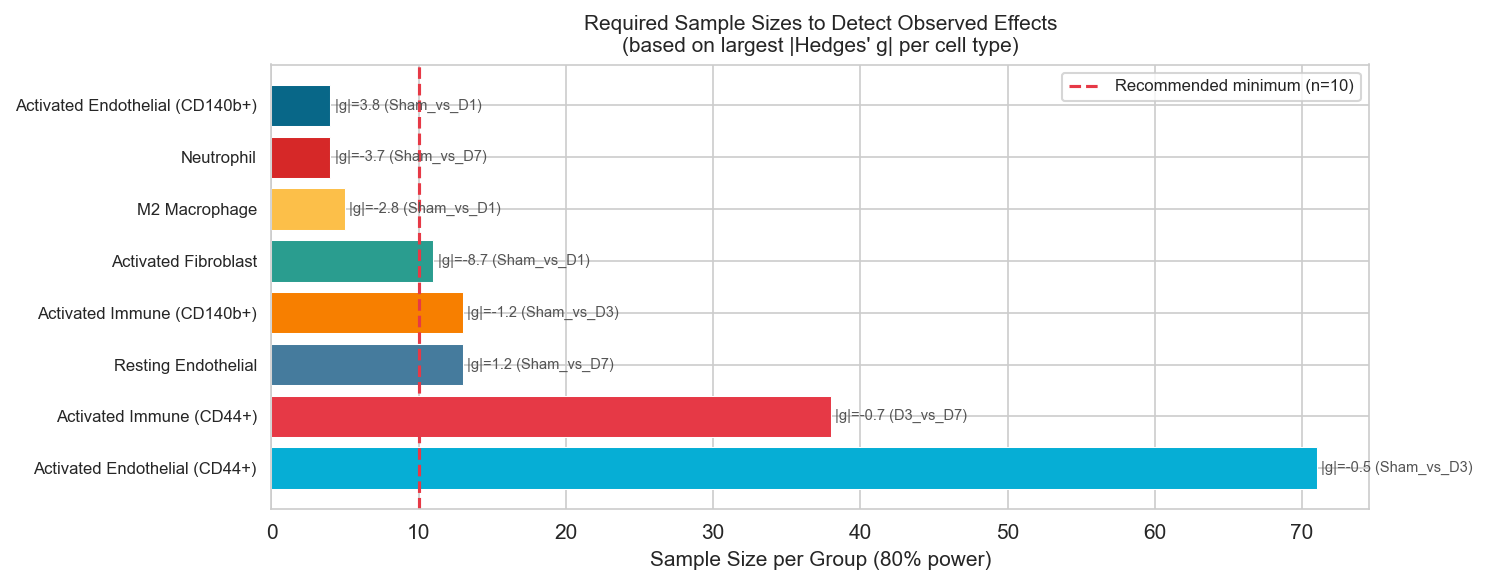

In [18]:
# --- 6b. Power analysis ---
if power_df is not None and len(power_df) > 0:
    power_sorted = power_df.sort_values('n_required_80pct')

    fig, ax = plt.subplots(figsize=(10, 4))
    colors_pwr = [CT_COLORS.get(ct, '#999') for ct in power_sorted['cell_type']]
    bars = ax.barh(range(len(power_sorted)), power_sorted['n_required_80pct'],
                   color=colors_pwr, edgecolor='white', linewidth=0.5)

    for i, (_, row) in enumerate(power_sorted.iterrows()):
        ax.text(row['n_required_80pct'] + 0.3, i,
                f"|g|={row['max_hedges_g']:.1f} ({row['comparison_at_max']})",
                fontsize=7, va='center', color='#555')

    ax.axvline(10, color='#E63946', linestyle='--', linewidth=1.5,
               label='Recommended minimum (n=10)')
    ax.set_yticks(range(len(power_sorted)))
    ax.set_yticklabels([ct_label(ct) for ct in power_sorted['cell_type']], fontsize=8)
    ax.set_xlabel('Sample Size per Group (80% power)')
    ax.set_title('Required Sample Sizes to Detect Observed Effects\n'
                 '(based on largest |Hedges\' g| per cell type)', fontsize=10)
    ax.legend(fontsize=8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Power analysis data not available.')

### Recommendations for Follow-Up Studies

Based on the pre-registered effect sizes (`endpoint_summary.csv`), reported as n_required ranges across three Bayesian priors (skeptical N(0, 0.5²) / neutral N(0, 1.0²) / optimistic N(0, 2.0²)). **The range IS the finding**; pick the prior matching your own scepticism about the pilot effects.

1. **Sample size — robust co-headline endpoints** (three-prior range; pick a prior matching your scepticism):
   - Triple-overlap fraction Sham→D7 (Family C): n range 4-158 (4 / 17 / 158)
   - Background CD44+ activation Sham→D7 (Family C): n range 5-160 (5 / 18 / 160)
   - Stromal-only lineage CLR shift Sham→D7 (Family A, robust under both normalization regimes): n range 11-244 (11 / 34 / 244)
   - Triple-positive interface CLR Sham→D7 (Family A, robust under Sham-ref): n likely several-tens to several-hundreds across priors
   - CD140b+ within-compartment CD44+ rate: n range 14-276 (14 / 39 / 276)
2. **Sample size — fragile / methods-flagged endpoints** (do NOT power a follow-up around these without first resolving the underlying issue):
   - Endothelial-only CLR Sham→D7: per-ROI gives n range 7-175 (7 / 22 / 175) but normalization-collapses; treat the per-ROI numbers as upper-bound noise floor, NOT a power target.
   - Family B (continuous neighborhood): 100% threshold-sensitive at this n; defer until n ≥ 10 OR redesign with stable normalization
3. **Methodological priorities for the follow-up cohort**:
   - **Switch the cell type annotation engine to a global / Sham-reference threshold** rather than per-ROI sigmoid normalization. Gate 6 of this pilot showed the per-ROI normalization can manufacture apparent CLR shifts (endothelial-only collapse) and compress real ones (triple-positive amplification under Sham-ref). The fix is upstream of all downstream effect sizes.
   - **Expanded panel**: 20+ markers to reduce the ~22% no-lineage fraction (tubular epithelium markers, additional immune subsets)
   - **Longitudinal design**: track the same animals across timepoints (requires survival surgery model) to separate biological variability from temporal trends
   - **Pathway enrichment**: with 20+ markers, formal gene set enrichment against INDRA-derived pathways becomes feasible (currently precluded at n=8 genes)
   - **Regional stratification**: formal paired analysis (Wilcoxon signed-rank) for cortex vs. medulla comparisons from the same mouse

---
*Analysis pipeline: IMC → SLIC superpixel segmentation → arcsinh transformation → boolean gating + continuous memberships → differential abundance (mouse-level, Hedges' g, BH FDR) → temporal interface analysis (3 families, Sham-reference + CLR, threshold sensitivity, normalization-mode sensitivity, Bayesian shrinkage under 3 priors, Hedges & Olkin 1985 variance) → neighborhood enrichment (kNN permutation) → INDRA/CoGEx knowledge graph annotation. See `analysis_plans/temporal_interfaces_plan.md` for full Phase 2 methodology and `METHODS.md` for the upstream pipeline.*

*Methods validation: data I/O integrity confirmed by Steinbock concordance benchmark (`notebooks/methods_validation/benchmarks/steinbock_concordance.ipynb`); discretization trade-offs in `notebooks/methods_validation/01_technical_methods/gradient_discretization.ipynb`.*
